Fig 1

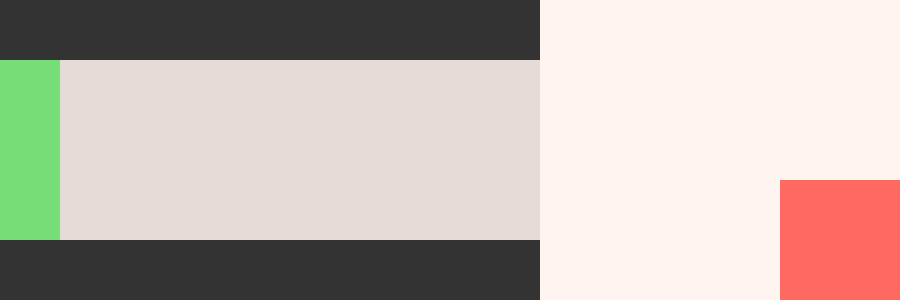

In [8]:
import numpy as np
from PIL import Image, ImageDraw

# 1. Setup the Mask
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# 2. Settings
cell_size = 60
rows, cols = mask.shape

# Revised Palette
colors = {
    'wall':           (51, 51, 51),    # Dark Grey
    'shelter':        (119, 221, 119), # Pastel Green
    'threat':         (255, 105, 97),  # Pastel Red
    # Split floor colors
    'floor_corridor': (230, 220, 215), # Light Grey
    'floor_chamber':  (255, 245, 240)  # Bright White
}

# 3. Create Image Canvas
img = Image.new('RGB', (cols * cell_size, rows * cell_size), colors['wall'])
draw = ImageDraw.Draw(img)

# 4. Draw the Grid
for r in range(rows):
    for c in range(cols):
        x0, y0 = c * cell_size, r * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        
        # Determine Color Priority: Wall -> Shelter -> Threat -> Floor Zone
        if not mask[r, c]:
            fill = colors['wall']
        elif c == 0 and 1 <= r <= 3:      # Shelter
            fill = colors['shelter']
        elif c >= 13 and r >= 3:          # Threat
            fill = colors['threat']
        else:
            # It's floor, check zone based on column index
            # Columns 0-8 are corridor, 9-14 are chamber
            if c <= 8:
                fill = colors['floor_corridor']
            else:
                fill = colors['floor_chamber']
            
        # Draw borderless rectangle (removed outline argument)
        draw.rectangle([x0, y0, x1, y1], fill=fill)

# 5. Display
img

In [6]:
import pandas as pd
import numpy as np

final_mask = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
])


active_cells = np.argwhere(final_mask == 1) 
# Create a dictionary to map (row, col) to a zero-indexed bin ID (0-56)
bin_id_map = {tuple(pos): i for i, pos in enumerate(active_cells)}

def get_closest_bin(r, c):
    if final_mask[r, c] == 1:
        return bin_id_map[(r, c)]
    
    # Calculate Euclidean distance to all active cells
    distances = np.sum((active_cells - np.array([r, c]))**2, axis=1)
    nearest_idx = np.argmin(distances)
    nearest_r, nearest_c = active_cells[nearest_idx]
    
    return bin_id_map[(nearest_r, nearest_c)]

def map_position(row, min_x, min_y, max_x, max_y, n_rows=5, n_cols=15):
    # Normalize and find raw grid coordinates
    x_norm = np.clip((row['Center_x'] - min_x) / (max_x - min_x), 0, 0.999)
    y_norm = np.clip((row['Center_y'] - min_y) / (max_y - min_y), 0, 0.999)
    
    r = int(np.floor(y_norm * n_rows))
    c = int(np.floor(x_norm * n_cols))
    
    # Return the mapped bin ID using nearest-neighbor logic
    return get_closest_bin(r, c)

def get_trajectory(df, n_steps=2000):
    df_filtered = df.copy()
    # Coarse-grain into 2000 steps
    df_filtered['step_number'] = np.linspace(0, n_steps, len(df_filtered), endpoint=False).astype(int)
    # Aggregate mean position per step
    coarse_data = df_filtered.groupby('step_number').agg({
        'Center_x': 'mean',
        'Center_y': 'mean'
    }).reset_index()

    min_x, max_x = df_filtered['Center_x'].min(), df_filtered['Center_x'].max()
    min_y, max_y = df_filtered['Center_y'].min(), df_filtered['Center_y'].max()

    coarse_data['location'] = coarse_data.apply(map_position, axis=1, args=(min_x, min_y, max_x, max_y))
    final_table = coarse_data[['step_number', 'location']]

    return final_table


confidence_threshold = 0.8

df_16_pre = pd.read_csv(f'./dlc/DLC_all_batches/m16_investigation_hab3_cropped.csv', index_col=0)
df_16_pre = df_16_pre[df_16_pre['Center_p'] > confidence_threshold]
trajectory_16_pre = get_trajectory(df_16_pre, n_steps=2000)['location']

df_16_post = pd.read_csv(f'./dlc/DLC_all_batches/m16_investigation_def2_cropped.csv', index_col=0)
df_16_post = df_16_post[df_16_post['Center_p'] > confidence_threshold]
trajectory_16_post = get_trajectory(df_16_post, n_steps=2000)['location']

len(trajectory_16_pre)

2000

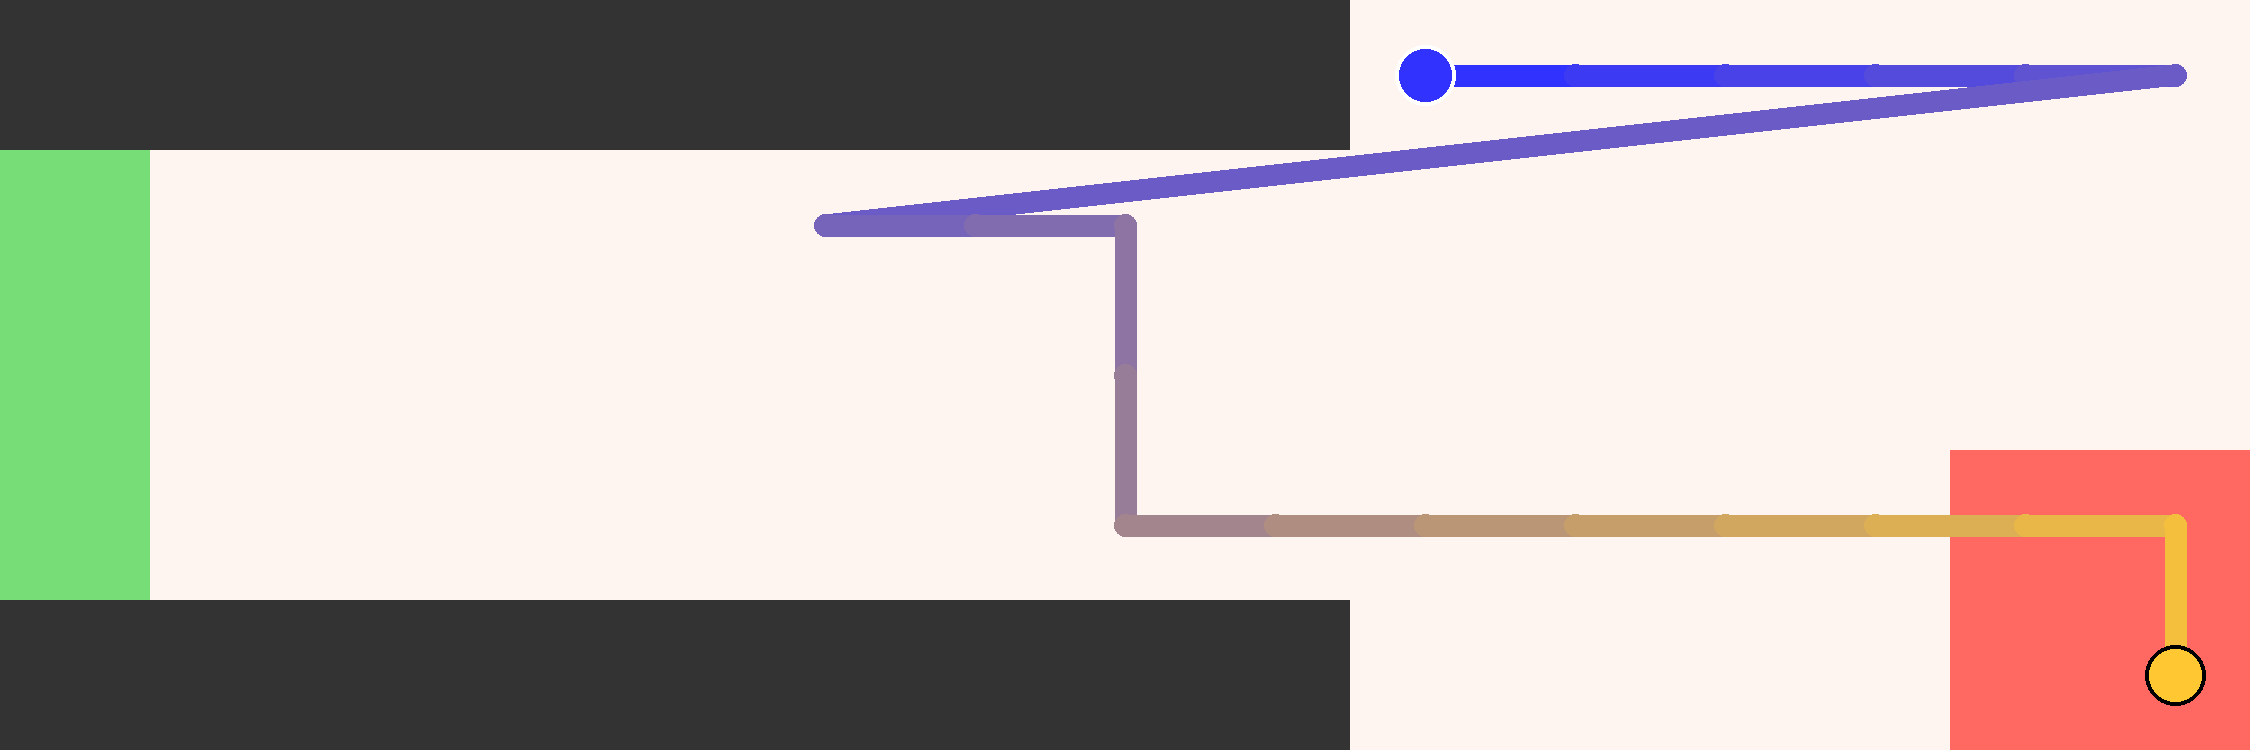

In [2]:
import numpy as np
from PIL import Image, ImageDraw


mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)


cell_size = 150  # Increased from 60 to 150 for sharp resolution
rows, cols = mask.shape

line_width = int(cell_size * 0.15)  # Thick trace line
joint_radius = line_width // 2      # Smooth joints
marker_radius = int(cell_size * 0.2) # Start/End dots


colors = {
    'wall':    (51, 51, 51),
    'floor':   (255, 245, 240), # Uniform Grey
    'shelter': (119, 221, 119),
    'threat':  (255, 105, 97),
    'start':   (50, 50, 255),   # Blue
    'end':     (255, 200, 50)   # Yellow
}


idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1


example_trajectory = [
    0, 1, 2, 3, 4, 5,              
    11, 12, 13, 28, 43, 44,        
    45, 46, 47, 48, 49, 50, 56     
]


def get_gradient_color(progress, start_rgb, end_rgb):
    r = int(start_rgb[0] + (end_rgb[0] - start_rgb[0]) * progress)
    g = int(start_rgb[1] + (end_rgb[1] - start_rgb[1]) * progress)
    b = int(start_rgb[2] + (end_rgb[2] - start_rgb[2]) * progress)
    return (r, g, b)


def draw_trace(traj):
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), colors['wall'])
    draw = ImageDraw.Draw(img)

    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            if not mask[r, c]:
                fill = colors['wall']
            elif c == 0 and 1 <= r <= 3:
                fill = colors['shelter']
            elif c >= 13 and r >= 3:
                fill = colors['threat']
            else:
                fill = colors['floor']
                
            draw.rectangle([x0, y0, x1, y1], fill=fill)


    if len(traj) > 1:
        points = []
        for idx in traj:
            r, c = idx_to_rc[idx]
            px = c * cell_size + cell_size // 2
            py = r * cell_size + cell_size // 2
            points.append((px, py))

        num_segments = len(points) - 1
        for i in range(num_segments):
            progress = i / max(1, num_segments)
            color = get_gradient_color(progress, colors['start'], colors['end'])
            
            p1 = points[i]
            p2 = points[i+1]

            draw.line([p1, p2], fill=color, width=line_width)
            
            draw.ellipse([p1[0]-joint_radius, p1[1]-joint_radius, 
                        p1[0]+joint_radius, p1[1]+joint_radius], fill=color)


        start_pt = points[0]
        end_pt = points[-1]
        
        # Start (Blue with White Border)
        draw.ellipse([start_pt[0]-marker_radius, start_pt[1]-marker_radius, 
                    start_pt[0]+marker_radius, start_pt[1]+marker_radius], 
                    fill=colors['start'], outline=(255,255,255), width=int(cell_size*0.03))
        
        # End (Yellow with Black Border)
        draw.ellipse([end_pt[0]-marker_radius, end_pt[1]-marker_radius, 
                    end_pt[0]+marker_radius, end_pt[1]+marker_radius], 
                    fill=colors['end'], outline=(0,0,0), width=int(cell_size*0.03))
        
    return img

# img.resize((cols*60, rows*60), resample=Image.LANCZOS) # Scale down for preview
example_img = draw_trace(example_trajectory)

example_img

pre


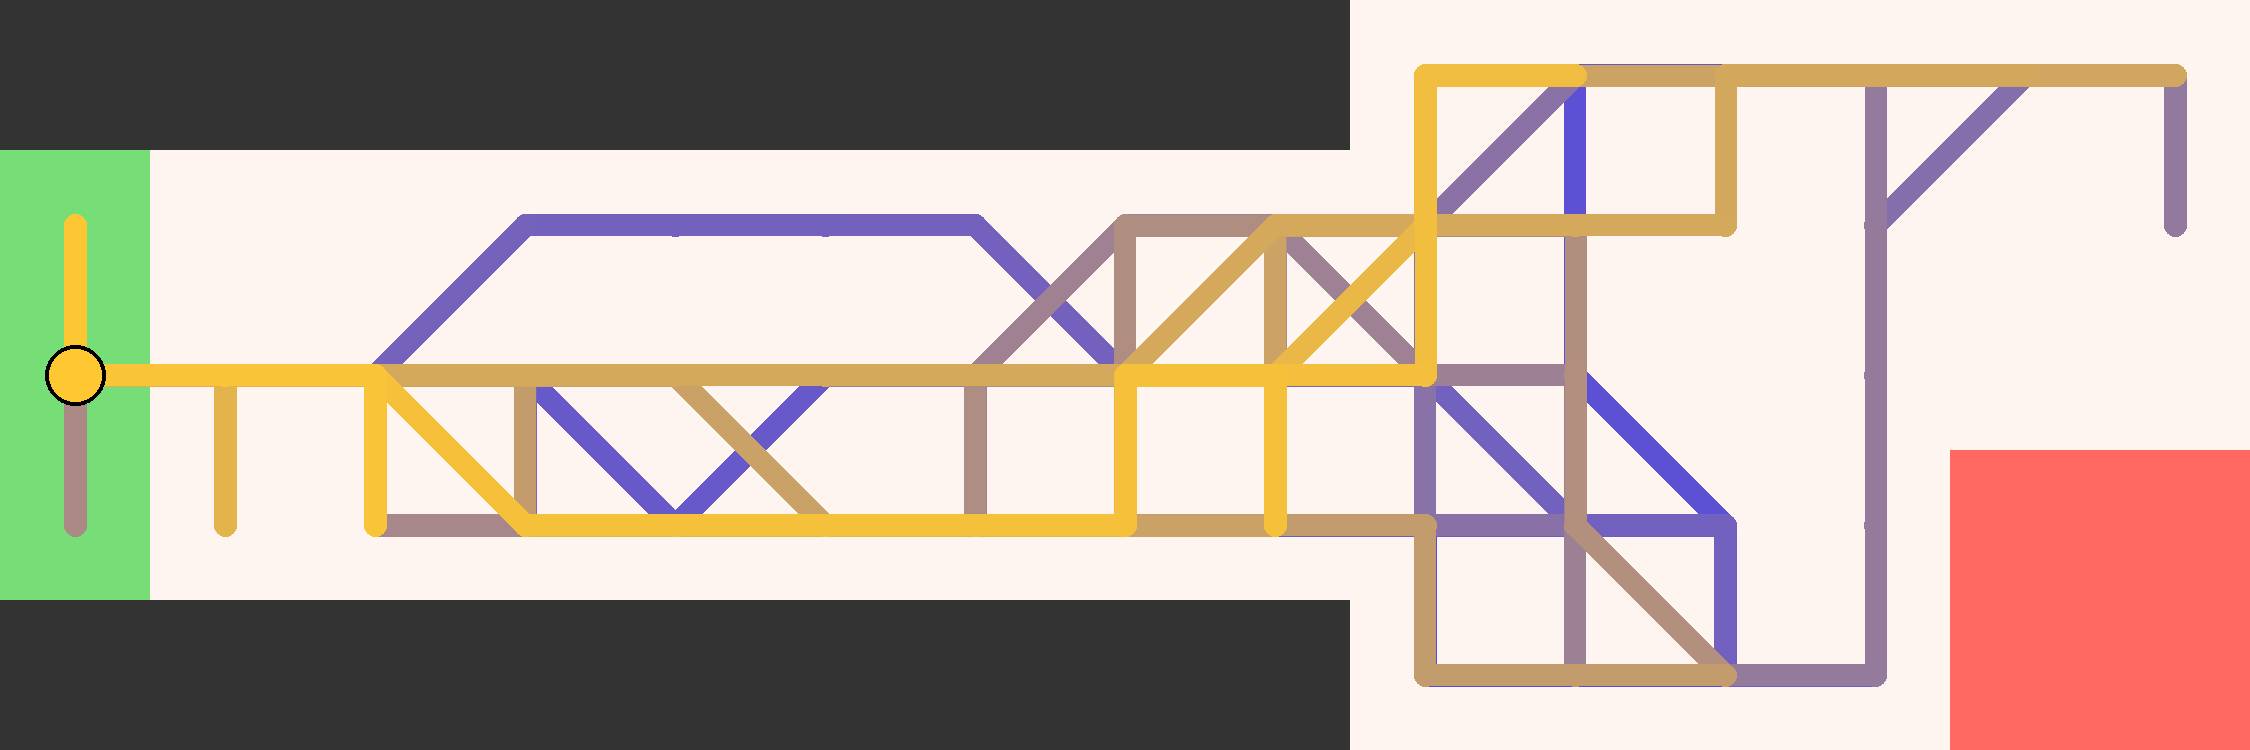

post


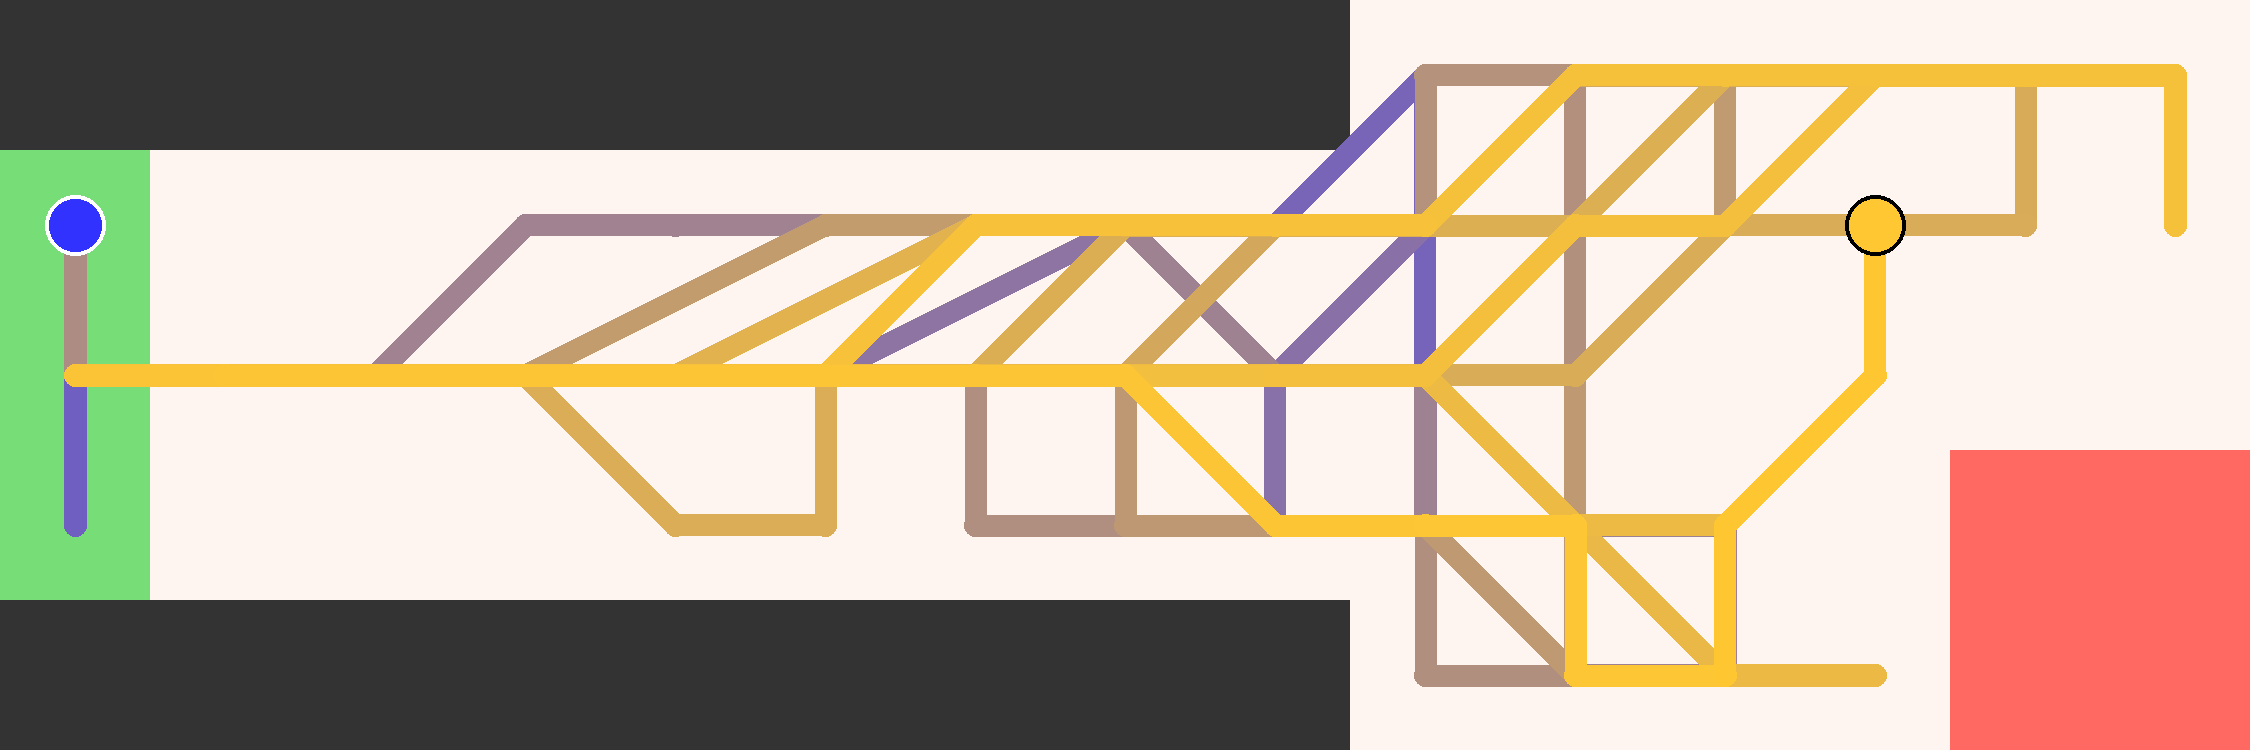

In [9]:
trace_16_pre = draw_trace(trajectory_16_pre)
trace_16_post = draw_trace(trajectory_16_post)
print("pre")
display(trace_16_pre)
print("post")
display(trace_16_post)

/tmp/ipykernel_2601/3801675453.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


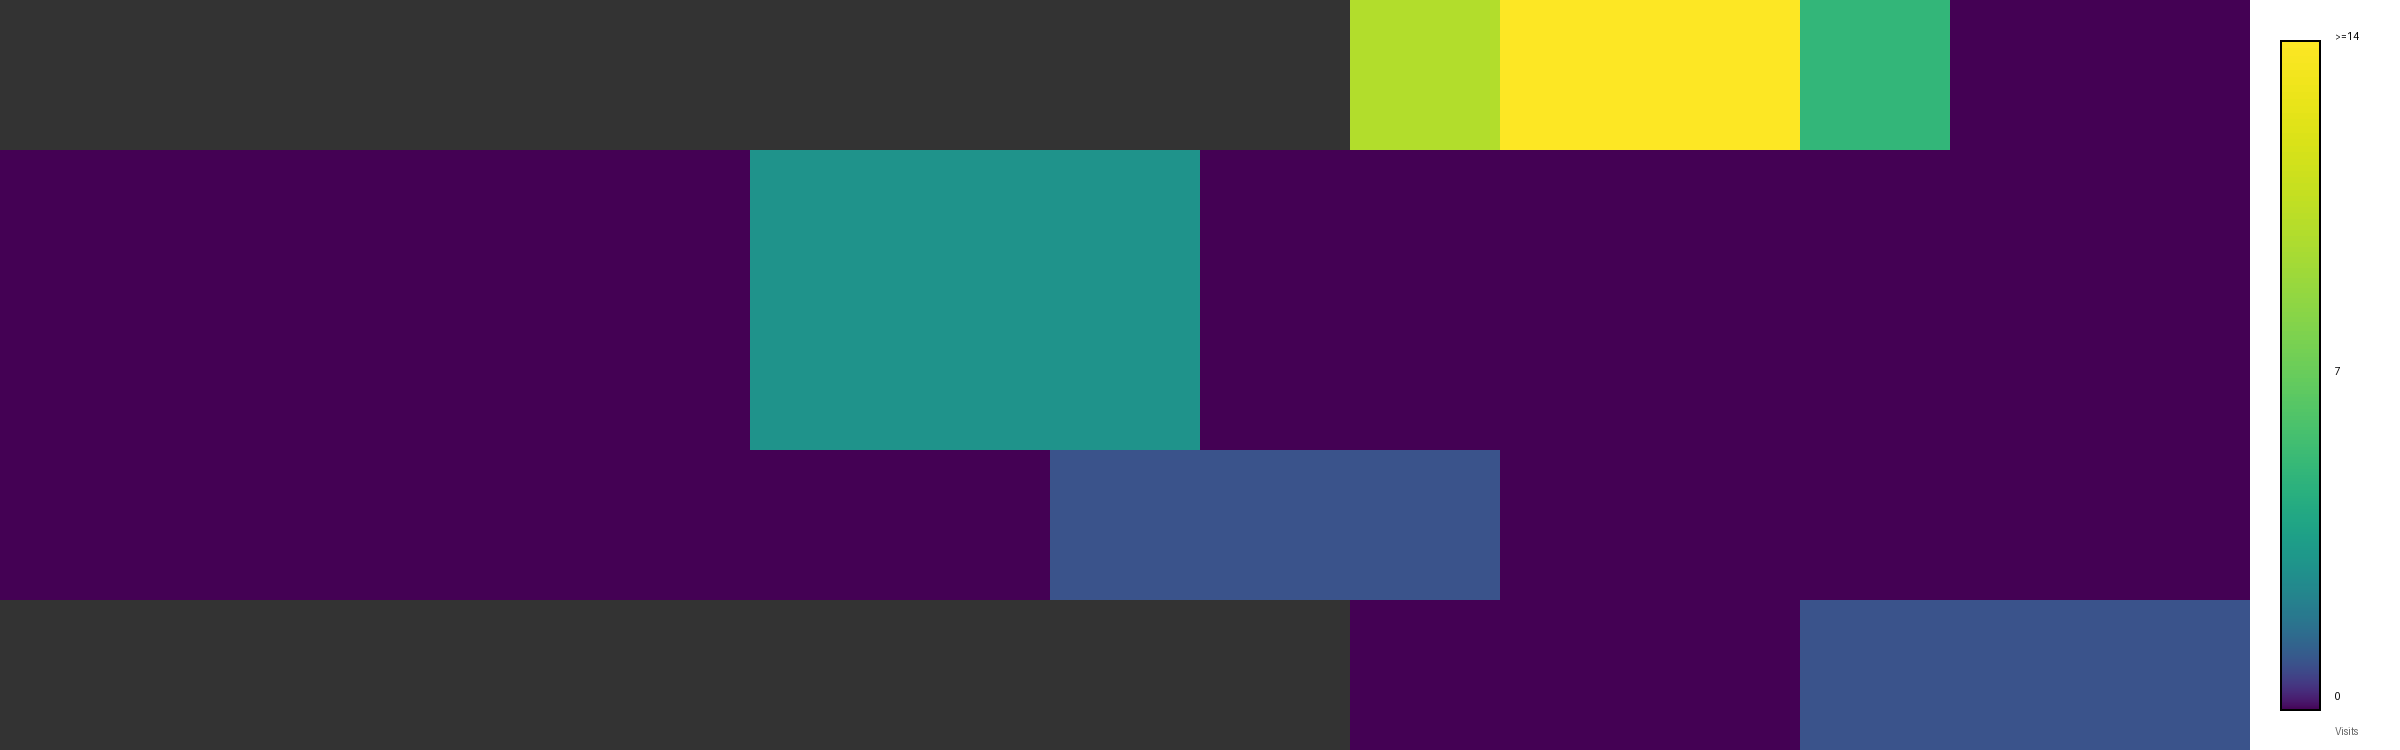

In [49]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from collections import Counter
import matplotlib.cm as cm
import math


mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

cell_size = 150
rows, cols = mask.shape


c_wall = (51, 51, 51)
c_floor = (255, 245, 240)


idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

example_trajectory = (
    [0, 1, 2, 1, 0, 1, 2, 3, 2, 1] * 5 + 
    [11, 12, 13, 28, 27, 26] * 3 +       
    [43, 44, 45, 56, 55, 54] * 1          
)


def draw_heatmap(traj, saturation_threshold=0.2, cmap='viridis', max_visits=None):
    # --- 1. Setup Data & Log Scale ---
    visit_counts = Counter(traj)
    traj_len = len(traj) if len(traj) > 0 else 1
    
    # Calculate the linear "Max" (The raw count that equals 100% brightness)
    if max_visits == None:
        max_visits = traj_len
    scale_max = int(max_visits * saturation_threshold)
    scale_max = max(scale_max, 1)
    
    # We use this denominator to normalize the log values to 0.0-1.0
    log_denominator = math.log(scale_max + 1)

    visit_map = {idx_to_rc[idx]: count for idx, count in visit_counts.items()}

    img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
    draw = ImageDraw.Draw(img)
    colormap = cm.get_cmap(cmap)

    # --- 2. Draw Grid (Log Colored) ---
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            if not mask[r, c]:
                draw.rectangle([x0, y0, x1, y1], fill=c_wall, outline=None)
            else:
                count = visit_map.get((r, c), 0)
                
                # Clamp the count to our max so we don't go out of bounds
                clamped_count = min(count, scale_max)
                
                # Apply Log Transform for COLOR only
                intensity = math.log(clamped_count + 1) / log_denominator
                
                rgba_float = colormap(intensity)
                r_val, g_val, b_val = [int(x*255) for x in rgba_float[:3]]
                
                draw.rectangle([x0, y0, x1, y1], fill=(r_val, g_val, b_val), outline=None)

    # --- 3. Draw Legend (Linear Ruler, Log Colors) ---
    legend_width = 150
    bar_width = 40
    padding = 40

    legend_img = Image.new('RGB', (legend_width, img.height), (255, 255, 255))
    legend_draw = ImageDraw.Draw(legend_img)

    bar_height = img.height - (padding * 2)
    bar_x = 30
    bar_y_start = padding

    for y in range(bar_height):
        # NORMAL SCALE: y moves linearly from 0 to bar_height
        progress = 1.0 - (y / bar_height) # 1.0 at top, 0.0 at bottom
        
        # Calculate the RAW NUMBER of visits this pixel height represents
        # e.g., if max is 100, at 50% height, this is exactly 50 visits.
        raw_count_at_pixel = progress * scale_max
        
        # LOG COLOR: Convert that linear raw number to the log color
        # This ensures the legend color matches the map color for that specific count
        intensity = math.log(raw_count_at_pixel + 1) / log_denominator
        
        rgba = colormap(intensity)
        color = tuple(int(c * 255) for c in rgba[:3])
        
        legend_draw.line(
            [(bar_x, bar_y_start + y), (bar_x + bar_width, bar_y_start + y)], 
            fill=color
        )

    # Draw Outline
    legend_draw.rectangle(
        [bar_x, bar_y_start, bar_x + bar_width, bar_y_start + bar_height], 
        outline=(0,0,0), width=2
    )

    try:
        font = ImageFont.truetype("arial.ttf", 30)
        font_sm = ImageFont.truetype("arial.ttf", 20)
    except IOError:
        font = ImageFont.load_default()
        font_sm = ImageFont.load_default()

    text_x = bar_x + bar_width + 15

    # --- Labels (Raw Linear Numbers) ---
    
    # Top Label (The Threshold)
    legend_draw.text((text_x, bar_y_start - 10), f">={scale_max}", fill=(0,0,0), font=font)
    
    # Middle Label (The Exact Halfway Point)
    # Because the bar is linear, we place this exactly in the middle pixels
    mid_y = bar_y_start + (bar_height // 2)
    mid_val = int(scale_max / 2)
    legend_draw.text((text_x, mid_y - 10), f"{mid_val}", fill=(0,0,0), font=font)
    
    # Bottom Label
    legend_draw.text((text_x, bar_y_start + bar_height - 20), "0", fill=(0,0,0), font=font)

    # Extra Info
    legend_draw.text((text_x, bar_y_start + bar_height + 15), "Visits", fill=(100,100,100), font=font_sm)

    final_w = img.width + legend_img.width
    final_h = img.height
    final_composite = Image.new('RGB', (final_w, final_h))
    final_composite.paste(img, (0, 0))
    final_composite.paste(legend_img, (img.width, 0))

    return final_composite

example_heat = draw_heatmap(example_trajectory)

display(example_heat)

/tmp/ipykernel_2601/3801675453.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


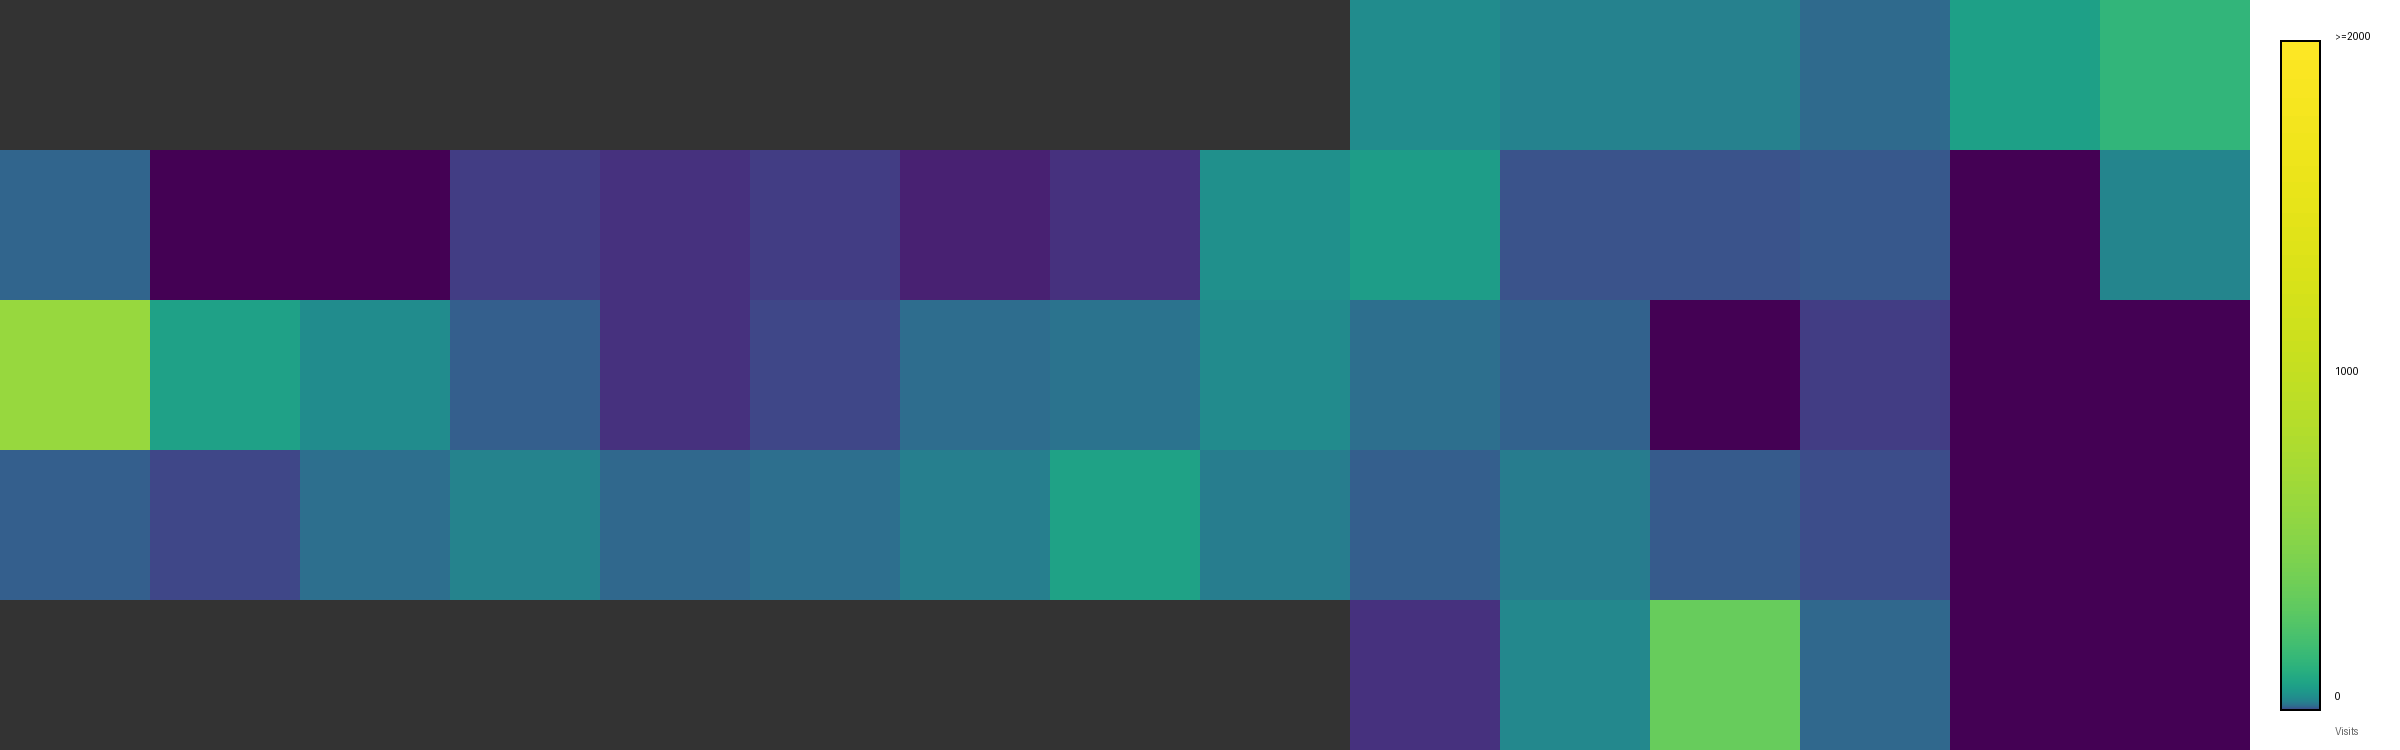

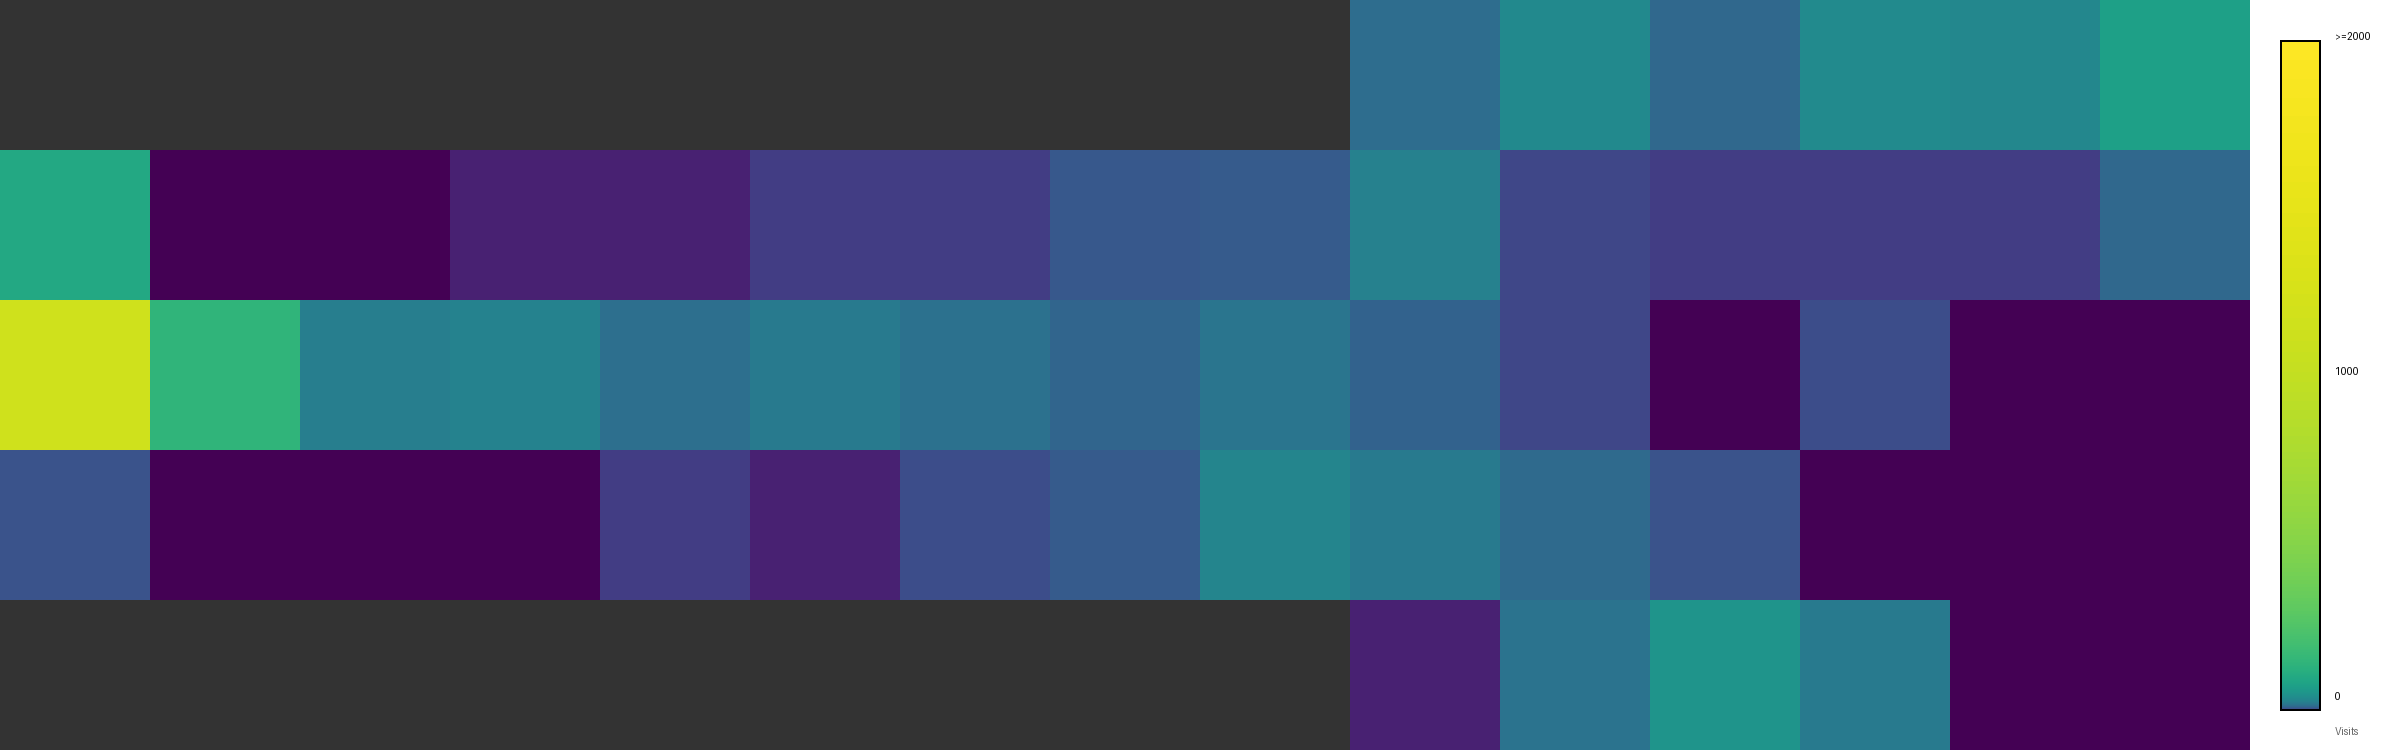

In [57]:
# max_v = max(max(Counter(trajectory_16_pre).values()), max(Counter(trajectory_16_post).values()))
max_v = 2000
thres = 1
heatmap_16_pre = draw_heatmap(trajectory_16_pre, saturation_threshold = thres, max_visits=max_v)
heatmap_16_post = draw_heatmap(trajectory_16_post, saturation_threshold = thres, max_visits=max_v)

display(heatmap_16_pre)
display(heatmap_16_post)

/tmp/ipykernel_3301/3741089154.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3301/3741089154.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3301/3741089154.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3301/3741089154.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3301/3741089154.py:123: F

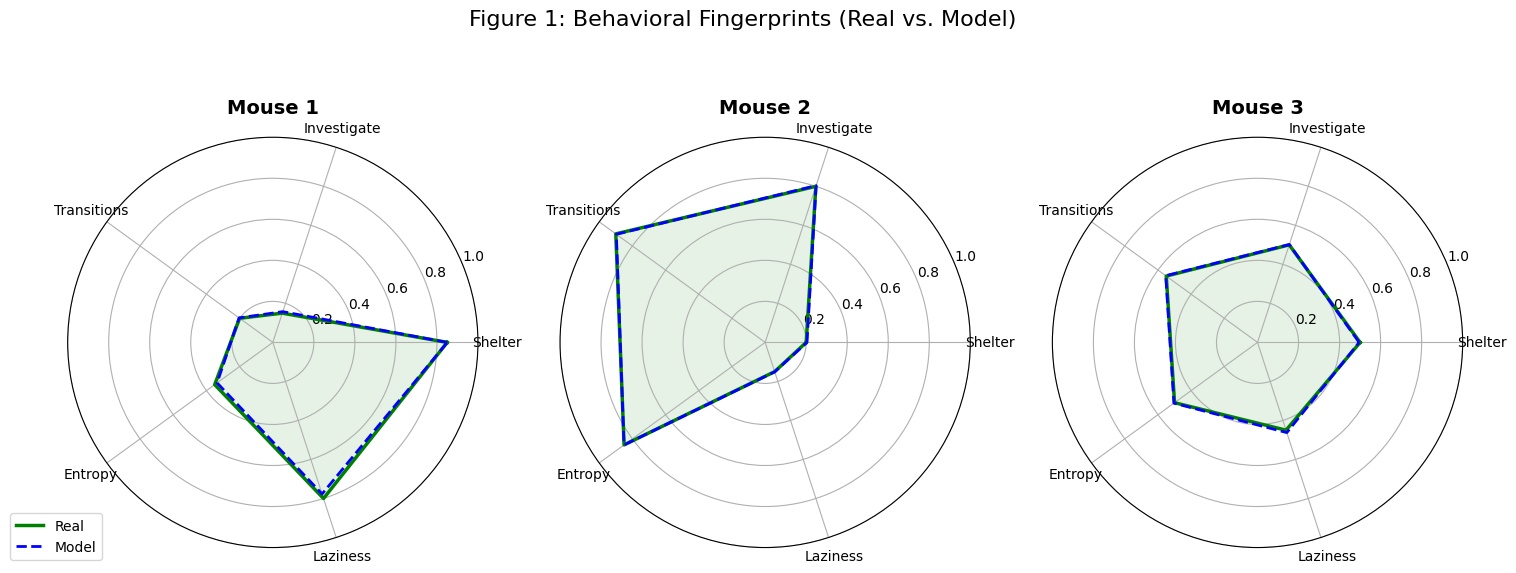

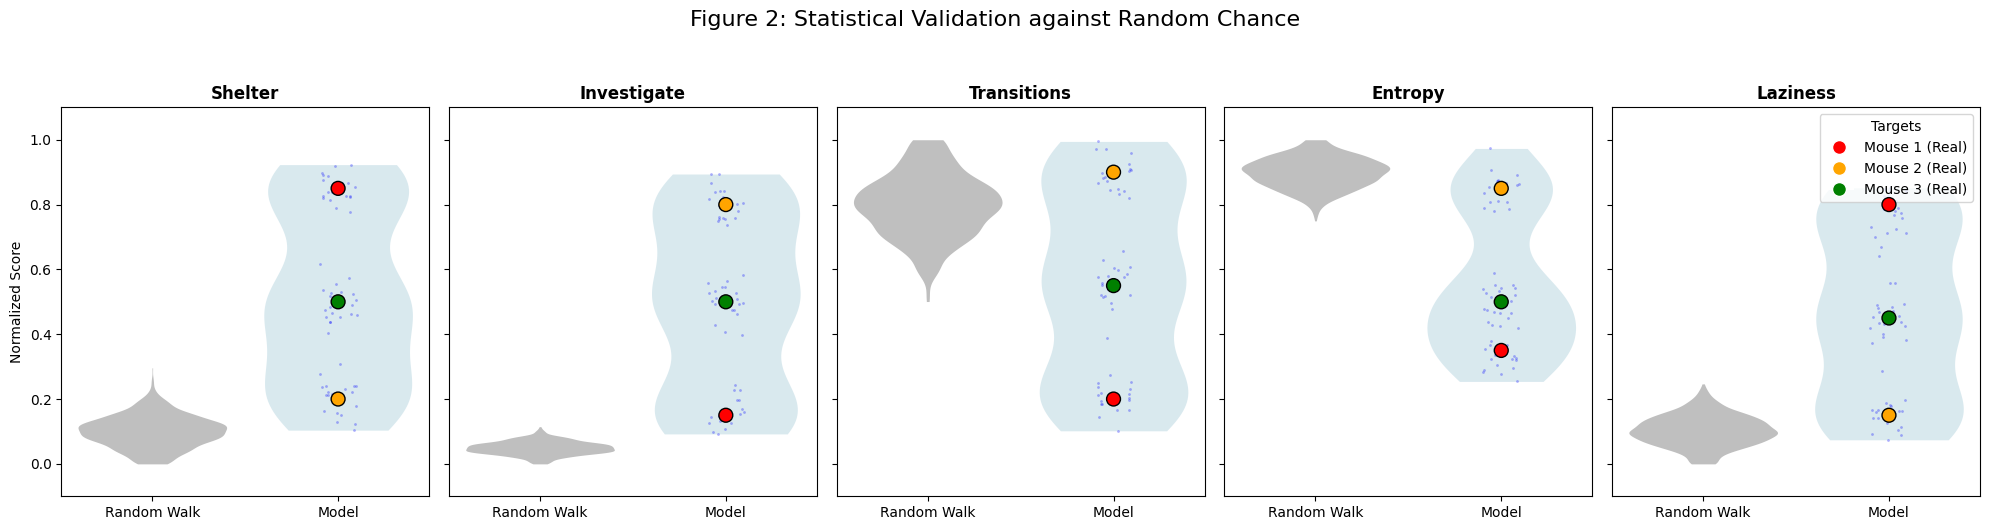

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from random_sim import random_metrics

# ==========================================
# 1. DATA GENERATION
# ==========================================
# Seed for reproducibility
np.random.seed(42)

# Metrics
metrics = ['Shelter', 'Investigate', 'Transitions', 'Entropy', 'Laziness'] # HERE 'TRANSITIONS' IS CONSIDERED A SINGLE METRIC, BUT IN MY DATA IT IS 4 DIFFERENT TRANSITIONS - USE ACCORDINGLY
num_vars = len(metrics)

# --- A. Real Mouse Data (N=3 distinct phenotypes) ---
# Mouse 1: "Anxious" (High Shelter, Low Investigate)
real_m1 = [0.85, 0.15, 0.20, 0.35, 0.80]
# Mouse 2: "Curious" (Low Shelter, High Investigate)
real_m2 = [0.20, 0.80, 0.90, 0.85, 0.15]
# Mouse 3: "Balanced" (Moderate everything)
real_m3 = [0.50, 0.50, 0.55, 0.50, 0.45]

real_data_map = {
    'Mouse 1': real_m1,
    'Mouse 2': real_m2,
    'Mouse 3': real_m3
}

# --- B. Model Data (N=3 Mice * 20 Runs each) ---
# Simulating stochastic variation around the "true" phenotype
model_data = []
for m_label, m_vals in real_data_map.items():
    for _ in range(20): # 20 runs per mouse
        # Add slight noise to simulate generative stochasticity
        noisy_vals = np.clip([v + np.random.normal(0, 0.05) for v in m_vals], 0, 1)
        model_data.append({'Mouse': m_label, 'Values': noisy_vals})

# --- C. Random Walk Data (N=1000 Baseline runs) ---
# Simulating a null distribution (e.g., high entropy, low shelter preference)
rw_data_dict = random_metrics(1000) # PROVIDES A DICT LIKE {'t_shelter': [], ... } with each list of the metric having 1000 items from 1000 runs 
rw_data = [] # COMPLETE THIS HERE

# ==========================================
# 2. PLOT 1: RADAR CHARTS (Fingerprints)
# ==========================================
# Helper to close the polygon loop
def close_loop(data):
    return np.concatenate((data, [data[0]]))

# Compute angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles_closed = np.concatenate((angles, [angles[0]]))

fig1, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))
fig1.suptitle('Figure 1: Behavioral Fingerprints (Real vs. Model)', fontsize=16, y=1.05)

mice_list = [('Mouse 1', real_m1), ('Mouse 2', real_m2), ('Mouse 3', real_m3)]

for ax, (name, real_vals) in zip(axes.flat, mice_list):
    # 1. Plot Real Data (Solid Line)
    ax.plot(angles_closed, close_loop(real_vals), color='green', linewidth=2.5, label='Real')
    ax.fill(angles_closed, close_loop(real_vals), color='green', alpha=0.1)
    
    # 2. Plot Model Mean (Dashed Line)
    # Get mean of model runs for this mouse
    m_runs = [d['Values'] for d in model_data if d['Mouse'] == name]
    m_mean = np.mean(m_runs, axis=0)
    ax.plot(angles_closed, close_loop(m_mean), color='blue', linewidth=2, linestyle='--', label='Model')
    
    # Formatting
    ax.set_xticks(angles)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_title(name, weight='bold', size=14, position=(0.5, 1.1))
    ax.set_ylim(0, 1)

# Add Legend to first plot
axes[0].legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# ==========================================
# 3. PLOT 2: COMPARATIVE VIOLIN PLOTS (Cognitive Gap)
# ==========================================
# Prepare DataFrame for Seaborn
rows = []

# Add Random Walk Data
for vals in rw_data:
    for i, metric in enumerate(metrics):
        rows.append({'Metric': metric, 'Value': vals[i], 'Type': 'Random Walk', 'Mouse': 'RW'})

# Add Model Data
for item in model_data:
    for i, metric in enumerate(metrics):
        rows.append({'Metric': metric, 'Value': item['Values'][i], 'Type': 'Model', 'Mouse': item['Mouse']})

# Add Real Data
for name, vals in real_data_map.items():
    for i, metric in enumerate(metrics):
        rows.append({'Metric': metric, 'Value': vals[i], 'Type': 'Real', 'Mouse': name})

df = pd.DataFrame(rows)

# Create Plot
fig2, axes2 = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
fig2.suptitle('Figure 2: Statistical Validation against Random Chance', fontsize=16, y=1.05)

colors = {'Random Walk': 'grey', 'Model': 'lightblue', 'Real': 'green'}

for i, metric in enumerate(metrics):
    ax = axes2[i]
    subset = df[df['Metric'] == metric]
    
    # 1. Violin Plots for Distributions (RW and Model)
    sns.violinplot(
        data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
        x='Type', y='Value',
        palette=colors, ax=ax,
        inner=None, linewidth=0, alpha=0.5, cut=0
    )
    
    # 2. Strip Plot for Model (to show particle density)
    sns.stripplot(
        data=subset[subset['Type'] == 'Model'],
        x='Type', y='Value',
        color='blue', size=2, alpha=0.3, jitter=True, ax=ax
    )

    # 3. Large Dots for Real Mice (The Ground Truths)
    # We plot them over the "Model" column to show fit
    real_subset = subset[subset['Type'] == 'Real']
    # We map x=1 because "Model" is at index 1 in the violin plot (0=RW, 1=Model)
    ax.scatter(
        x=[1]*len(real_subset), 
        y=real_subset['Value'], 
        c=['red', 'orange', 'green'], # Distinct colors for Mouse 1, 2, 3
        s=100, zorder=10, edgecolors='black', label='Real Mice'
    )

    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Normalized Score' if i==0 else '')
    ax.set_ylim(-0.1, 1.1)

# Add custom legend for the real mice dots
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Mouse 1 (Real)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Mouse 2 (Real)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Mouse 3 (Real)')
]
axes2[-1].legend(handles=legend_elements, loc='upper right', title="Targets")

plt.tight_layout()
plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2601/3623015175.py:49: SyntaxWarning: invalid escape sequence '\s'
  df_real = pd.read_csv(io.StringIO(real_txt), sep='\s+')
/tmp/ipykernel_2601/3623015175.py:50: SyntaxWarning: invalid escape sequence '\s'
  df_sim = pd.read_csv(io.StringIO(sim_txt), sep='\s+')


Setup complete
Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

Initialized - Agent postion: (1, 0), Thr

/tmp/ipykernel_2601/3623015175.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
/tmp/ipykernel_2601/3623015175.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
/tmp/ipykernel_2601/3623015175.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
/tmp/ipykernel_2601/3623015175.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is de

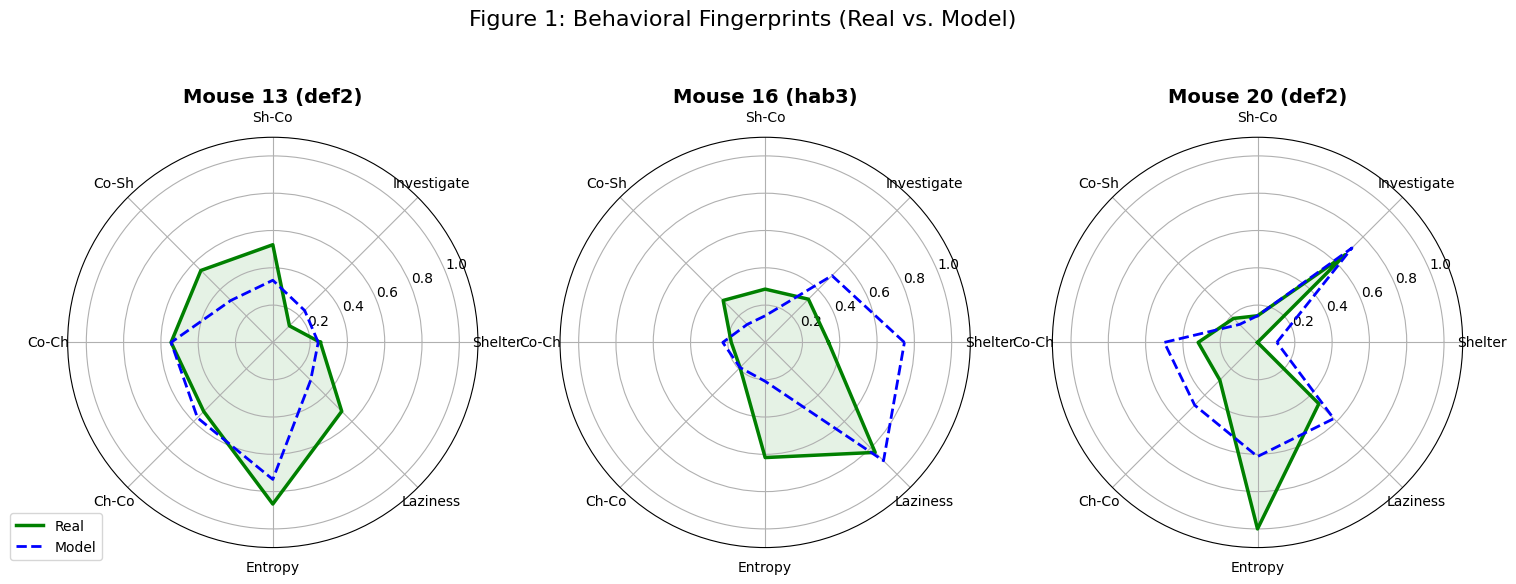

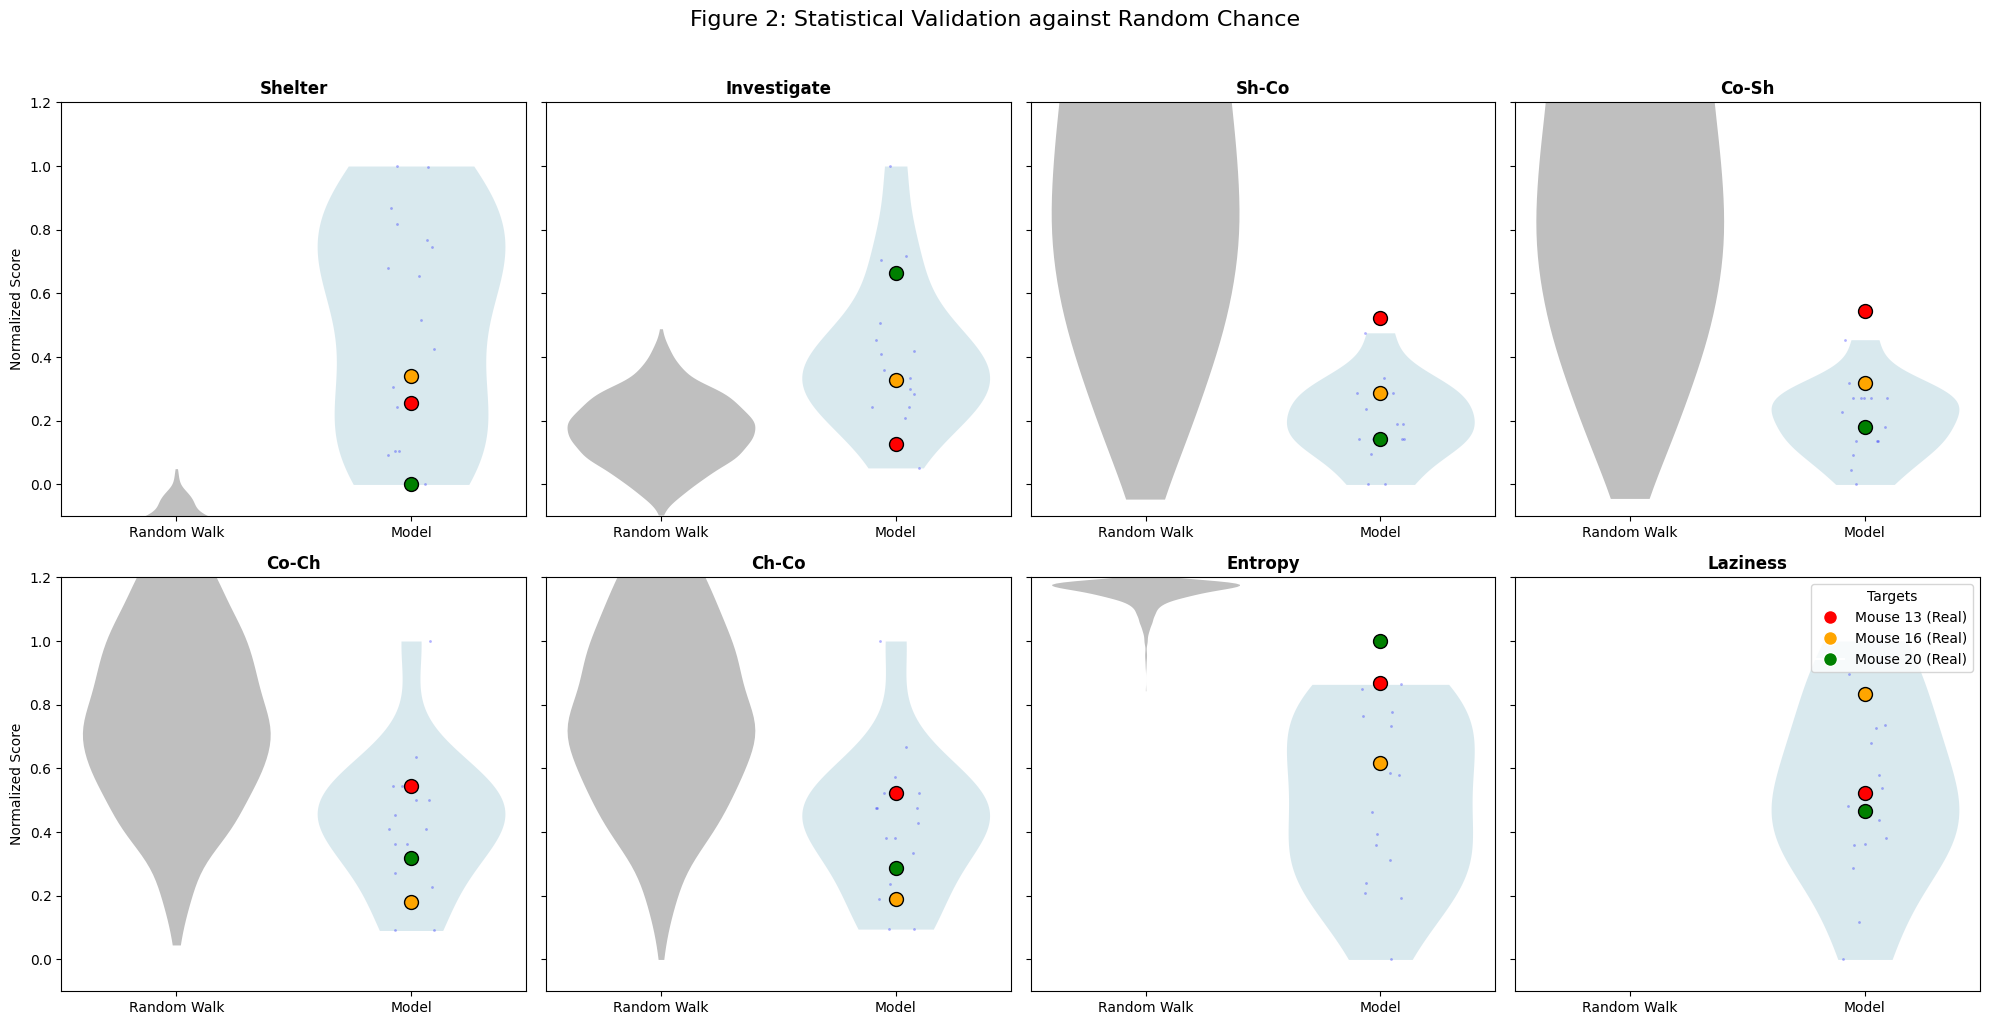

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import io
from random_sim import random_metrics

# ==========================================
# 1. DATA PARSING & PREPROCESSING
# ==========================================

real_txt = """mouse_number phase t_shelter t_investigating n_sh_co n_co_sh n_co_ch n_ch_co heatmap_entropy laziness
13 hab3 0.6485 0.1405 23 23 6 6 4.132956915 0.829
13 def2 0.312 0.101 13 13 15 14 4.721737822 0.795
14 hab3 0.562 0.044 18 18 12 12 3.909343409 0.856
14 def2 0.5385 0.053 14 14 8 8 3.818612692 0.853
15 hab3 0.5395 0.1345 22 22 3 3 3.864439473 0.846
15 def2 0.4255 0.1075 17 17 8 7 4.179584098 0.847
16 hab3 0.359 0.1925 8 8 7 7 3.919248356 0.871
16 def2 0.6935 0.0455 18 17 10 9 2.939803933 0.858
17 hab3 0.404 0.279 19 19 9 8 4.35692005 0.831
17 def2 0.664 0.062 15 15 5 5 3.364352495 0.879
18 hab3 0.306 0.218 13 14 14 14 4.994446817 0.783
18 def2 0.407 0.1615 15 15 11 10 4.643901027 0.814
19 hab3 0.363 0.14 7 8 13 13 4.720152234 0.811
19 def2 0.474 0.1875 18 19 12 12 4.61703006 0.803
20 hab3 0.293 0.1745 3 3 16 15 4.73309349 0.753
20 def2 0.1705 0.3455 5 5 10 9 5.151318048 0.781"""

sim_txt = """Name metric_entropy metric_n_ch_co metric_n_co_ch metric_n_co_sh metric_n_sh_co metric_t_investigating metric_t_shelter metric_laziness
LOSS_13_def2 4.296422916 15 15 8 9 0.1535 0.3055 0.7375
LOSS_13_hab3 3.195065402 11 11 6 6 0.2345 0.5965 0.8335
LOSS_14_def2 4.43724739 24 25 7 8 0.497 0.1705 0.6675
LOSS_14_hab3 2.554980742 10 11 5 6 0.173 0.6515 0.8475
LOSS_15_def2 2.940415636 13 13 5 5 0.1795 0.5335 0.7985
LOSS_15_hab3 3.092608564 8 9 3 4 0.207 0.624 0.8445
LOSS_16_def2 1.930290098 5 5 1 2 0.0675 0.725 0.9115
LOSS_16_hab3 2.602157206 7 8 4 5 0.2735 0.5845 0.8865
LOSS_17_def2 2.707225653 5 5 2 2 0.1385 0.724 0.896
LOSS_17_hab3 3.79658214 17 17 7 7 0.3635 0.4055 0.7745
LOSS_18_def2 3.41889804 13 14 4 5 0.2 0.548 0.785
LOSS_18_hab3 4.71291424 14 15 11 12 0.229 0.3405 0.6965
LOSS_19_def2 3.813127568 14 15 7 8 0.249 0.457 0.7605
LOSS_19_hab3 4.666456582 11 12 7 8 0.1535 0.228 0.7555
LOSS_20_def2 3.901667725 13 14 4 5 0.3685 0.228 0.8085
LOSS_20_hab3 4.395300543 12 12 7 8 0.195 0.221 0.756"""

# Load Dataframes
df_real = pd.read_csv(io.StringIO(real_txt), sep='\s+')
df_sim = pd.read_csv(io.StringIO(sim_txt), sep='\s+')

# Align Simulation column names with Real data
df_sim.columns = [c.replace('metric_', '') for c in df_sim.columns]
df_sim.rename(columns={'entropy': 'heatmap_entropy'}, inplace=True)

# Extract IDs for mapping
df_sim['mouse_number'] = df_sim['Name'].apply(lambda x: int(x.split('_')[1]))
df_sim['phase'] = df_sim['Name'].apply(lambda x: x.split('_')[2])

# Define exact metrics and display labels
metrics_raw = ['t_shelter', 't_investigating', 'n_sh_co', 'n_co_sh', 'n_co_ch', 'n_ch_co', 'heatmap_entropy', 'laziness']
display_metrics = ['Shelter', 'Investigate', 'Sh-Co', 'Co-Sh', 'Co-Ch', 'Ch-Co', 'Entropy', 'Laziness']
num_vars = len(metrics_raw)

# Normalization logic across all data types
combined_vals = pd.concat([df_real[metrics_raw], df_sim[metrics_raw]])
mins, maxs = combined_vals.min(), combined_vals.max()

def normalize_metrics(df):
    return (df[metrics_raw] - mins) / (maxs - mins)

df_real_norm = pd.concat([df_real[['mouse_number', 'phase']], normalize_metrics(df_real)], axis=1)
df_sim_norm = pd.concat([df_sim[['mouse_number', 'phase']], normalize_metrics(df_sim)], axis=1)

# --- C. Random Walk Data ---
# Map provided dictionary format to a normalized DataFrame
rw_raw_dict = random_metrics(1000) 
df_rw = pd.DataFrame(rw_raw_dict)
# Handle potential name mismatches in random_metrics dictionary if they differ from metrics_raw
if 'entropy' in df_rw.columns and 'heatmap_entropy' not in df_rw.columns:
    df_rw.rename(columns={'entropy': 'heatmap_entropy'}, inplace=True)
df_rw_norm = normalize_metrics(df_rw)

# ==========================================
# 2. PLOT 1: RADAR CHARTS (Fingerprints)
# ==========================================

def close_loop(data):
    return np.concatenate((data, [data[0]]))

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles_closed = np.concatenate((angles, [angles[0]]))

fig1, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))
fig1.suptitle('Figure 1: Behavioral Fingerprints (Real vs. Model)', fontsize=16, y=1.05)

# Selection as requested: 13(def2), 16(hab3), 20(def2)
target_mice = [(13, 'def2'), (16, 'hab3'), (20, 'def2')]

for ax, (m_id, p_id) in zip(axes.flat, target_mice):
    # Fetch Real
    real_vals = df_real_norm[(df_real_norm['mouse_number'] == m_id) & (df_real_norm['phase'] == p_id)][metrics_raw].values.flatten()
    # Fetch Model
    model_vals = df_sim_norm[(df_sim_norm['mouse_number'] == m_id) & (df_sim_norm['phase'] == p_id)][metrics_raw].values.flatten()
    
    # 1. Plot Real Data
    ax.plot(angles_closed, close_loop(real_vals), color='green', linewidth=2.5, label='Real')
    ax.fill(angles_closed, close_loop(real_vals), color='green', alpha=0.1)
    
    # 2. Plot Model Data
    ax.plot(angles_closed, close_loop(model_vals), color='blue', linewidth=2, linestyle='--', label='Model')
    
    ax.set_xticks(angles)
    ax.set_xticklabels(display_metrics, fontsize=10)
    ax.set_title(f"Mouse {m_id} ({p_id})", weight='bold', size=14, position=(0.5, 1.1))
    ax.set_ylim(0, 1.1)

axes[0].legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# ==========================================
# 3. PLOT 2: COMPARATIVE VIOLIN PLOTS
# ==========================================

rows = []
for i, m_key in enumerate(metrics_raw):
    m_label = display_metrics[i]
    # Random Walk
    for v in df_rw_norm[m_key]:
        rows.append({'Metric': m_label, 'Value': v, 'Type': 'Random Walk'})
    # Model
    for v in df_sim_norm[m_key]:
        rows.append({'Metric': m_label, 'Value': v, 'Type': 'Model'})
    # Real (Target Mice)
    for m_id, p_id in target_mice:
        v = df_real_norm[(df_real_norm['mouse_number'] == m_id) & (df_real_norm['phase'] == p_id)][m_key].values[0]
        rows.append({'Metric': m_label, 'Value': v, 'Type': 'Real', 'Mouse': f'Mouse {m_id}'})

df_viz = pd.DataFrame(rows)

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
fig2.suptitle('Figure 2: Statistical Validation against Random Chance', fontsize=16, y=1.02)

colors = {'Random Walk': 'grey', 'Model': 'lightblue'}
mouse_dots = {'Mouse 13': 'red', 'Mouse 16': 'orange', 'Mouse 20': 'green'}

for i, m_label in enumerate(display_metrics):
    ax = axes2.flat[i]
    subset = df_viz[df_viz['Metric'] == m_label]
    
    sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])], 
                   x='Type', y='Value', palette=colors, ax=ax, inner=None, linewidth=0, alpha=0.5, cut=0)
    
    sns.stripplot(data=subset[subset['Type'] == 'Model'], 
                  x='Type', y='Value', color='blue', size=2, alpha=0.3, jitter=True, ax=ax)

    # Plot the 3 target real mice
    real_subset = subset[subset['Type'] == 'Real']
    for mid_label, color in mouse_dots.items():
        val = real_subset[real_subset['Mouse'] == mid_label]['Value'].values[0]
        ax.scatter(x=[1], y=[val], c=color, s=100, zorder=10, edgecolors='black')

    ax.set_title(m_label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Normalized Score' if i % 4 == 0 else '')
    ax.set_ylim(-0.1, 1.2)

# Custom legend for targets
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=f'{k} (Real)') 
                   for k, c in mouse_dots.items()]
axes2.flat[-1].legend(handles=legend_elements, loc='upper right', title="Targets")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2601/69280441.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
/tmp/ipykernel_2601/69280441.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
/tmp/ipykernel_2601/69280441.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
/tmp/ipykernel_2601/69280441.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

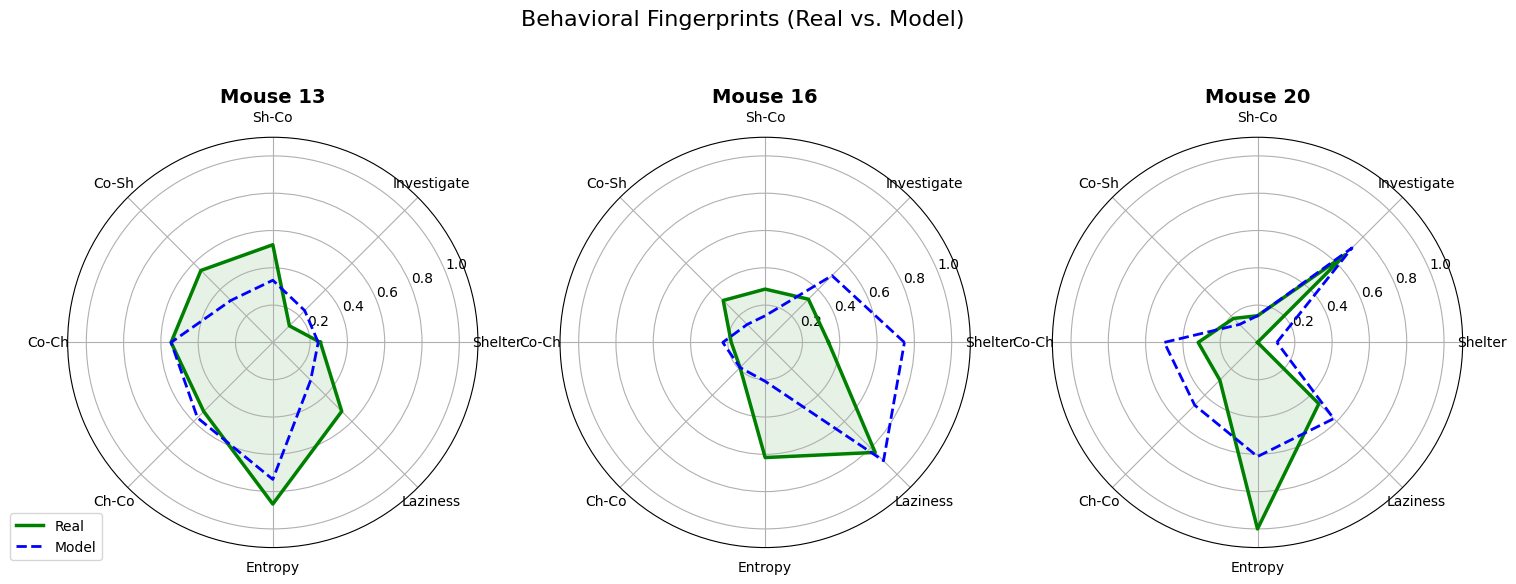

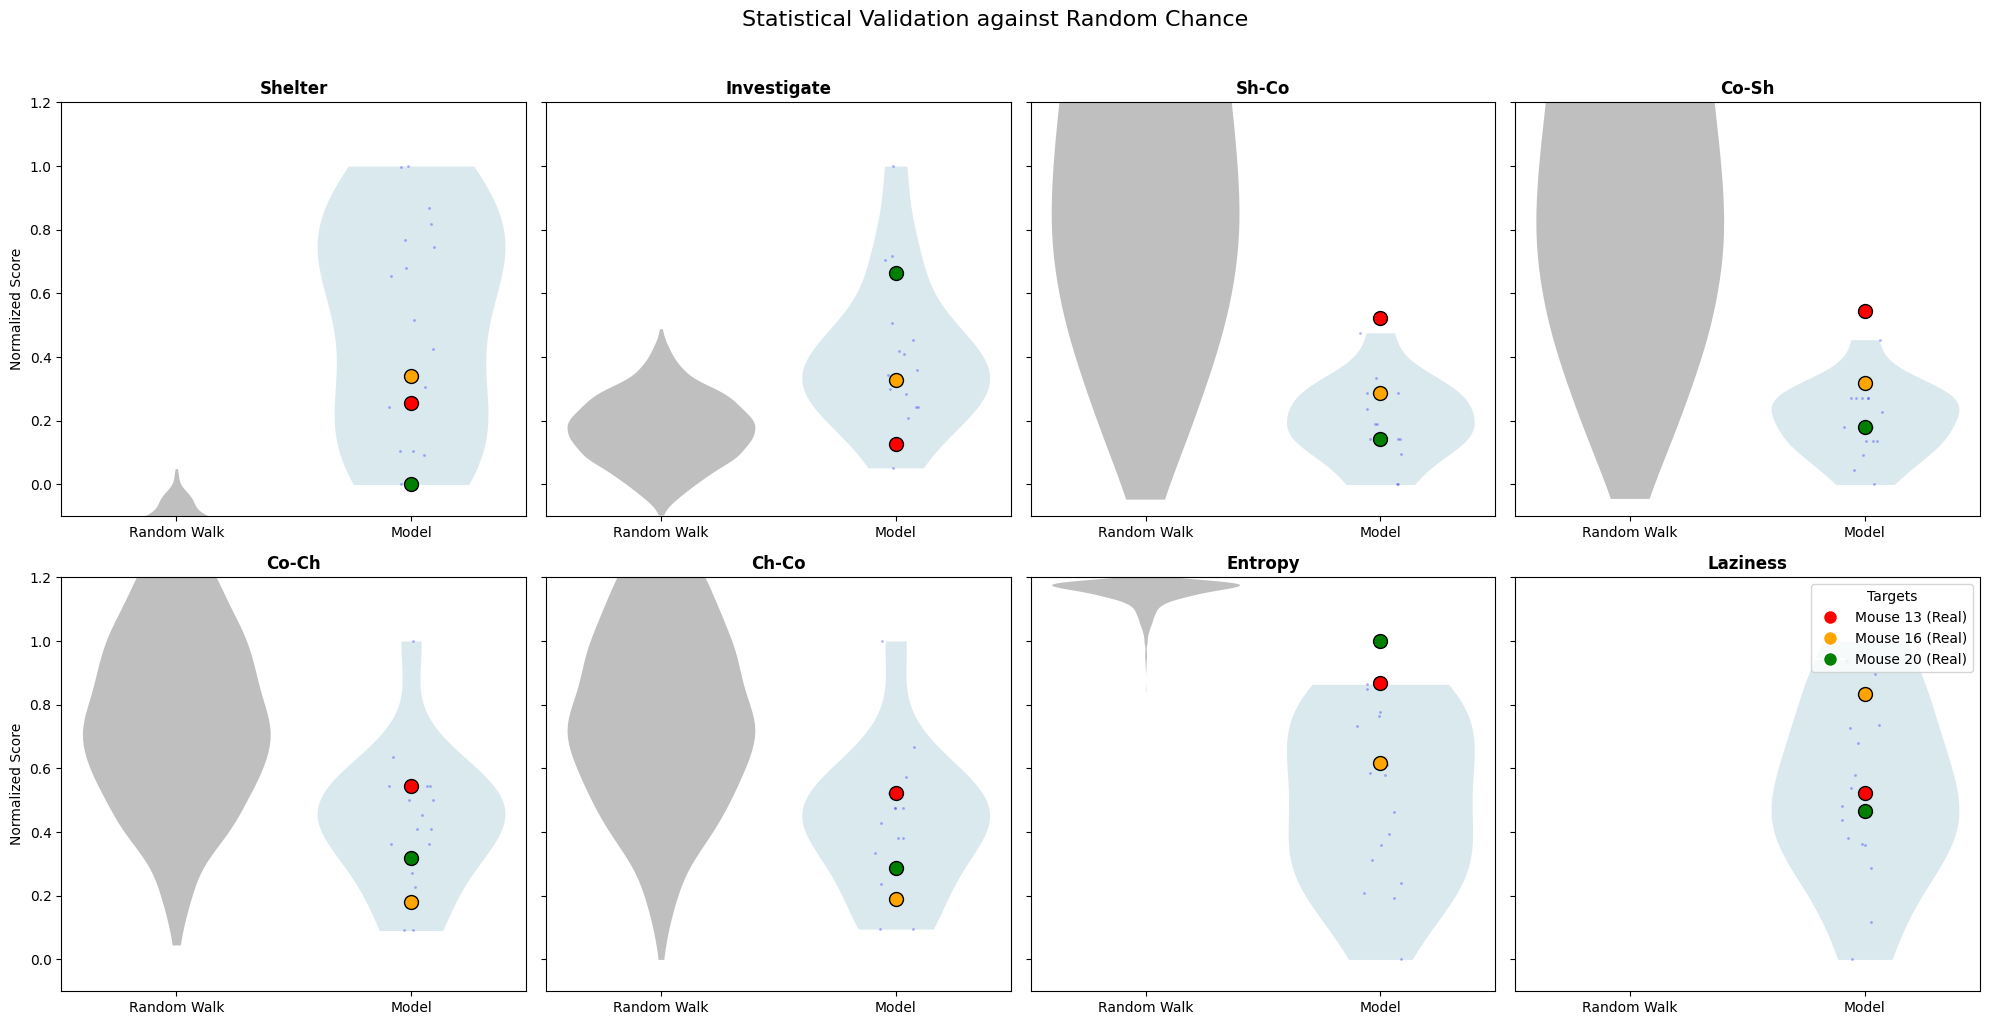

In [67]:
# ==========================================
# 2. PLOT 1: RADAR CHARTS (Fingerprints)
# ==========================================

def close_loop(data):
    return np.concatenate((data, [data[0]]))

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles_closed = np.concatenate((angles, [angles[0]]))

fig1, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))
fig1.suptitle('Behavioral Fingerprints (Real vs. Model)', fontsize=16, y=1.05)

# Selection as requested: 13(def2), 16(hab3), 20(def2)
target_mice = [(13, 'def2'), (16, 'hab3'), (20, 'def2')]

for ax, (m_id, p_id) in zip(axes.flat, target_mice):
    # Fetch Real
    real_vals = df_real_norm[(df_real_norm['mouse_number'] == m_id) & (df_real_norm['phase'] == p_id)][metrics_raw].values.flatten()
    # Fetch Model
    model_vals = df_sim_norm[(df_sim_norm['mouse_number'] == m_id) & (df_sim_norm['phase'] == p_id)][metrics_raw].values.flatten()
    
    # 1. Plot Real Data
    ax.plot(angles_closed, close_loop(real_vals), color='green', linewidth=2.5, label='Real')
    ax.fill(angles_closed, close_loop(real_vals), color='green', alpha=0.1)
    
    # 2. Plot Model Data
    ax.plot(angles_closed, close_loop(model_vals), color='blue', linewidth=2, linestyle='--', label='Model')
    
    ax.set_xticks(angles)
    ax.set_xticklabels(display_metrics, fontsize=10)
    ax.set_title(f"Mouse {m_id}", weight='bold', size=14, position=(0.5, 1.1))
    ax.set_ylim(0, 1.1)

axes[0].legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# ==========================================
# 3. PLOT 2: COMPARATIVE VIOLIN PLOTS
# ==========================================

rows = []
for i, m_key in enumerate(metrics_raw):
    m_label = display_metrics[i]
    # Random Walk
    for v in df_rw_norm[m_key]:
        rows.append({'Metric': m_label, 'Value': v, 'Type': 'Random Walk'})
    # Model
    for v in df_sim_norm[m_key]:
        rows.append({'Metric': m_label, 'Value': v, 'Type': 'Model'})
    # Real (Target Mice)
    for m_id, p_id in target_mice:
        v = df_real_norm[(df_real_norm['mouse_number'] == m_id) & (df_real_norm['phase'] == p_id)][m_key].values[0]
        rows.append({'Metric': m_label, 'Value': v, 'Type': 'Real', 'Mouse': f'Mouse {m_id}'})

df_viz = pd.DataFrame(rows)

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
fig2.suptitle('Statistical Validation against Random Chance', fontsize=16, y=1.02)

colors = {'Random Walk': 'grey', 'Model': 'lightblue'}
mouse_dots = {'Mouse 13': 'red', 'Mouse 16': 'orange', 'Mouse 20': 'green'}

for i, m_label in enumerate(display_metrics):
    ax = axes2.flat[i]
    subset = df_viz[df_viz['Metric'] == m_label]
    
    sns.violinplot(data=subset[subset['Type'].isin(['Random Walk', 'Model'])], 
                   x='Type', y='Value', palette=colors, ax=ax, inner=None, linewidth=0, alpha=0.5, cut=0)
    
    sns.stripplot(data=subset[subset['Type'] == 'Model'], 
                  x='Type', y='Value', color='blue', size=2, alpha=0.3, jitter=True, ax=ax)

    # Plot the 3 target real mice
    real_subset = subset[subset['Type'] == 'Real']
    for mid_label, color in mouse_dots.items():
        val = real_subset[real_subset['Mouse'] == mid_label]['Value'].values[0]
        ax.scatter(x=[1], y=[val], c=color, s=100, zorder=10, edgecolors='black')

    ax.set_title(m_label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Normalized Score' if i % 4 == 0 else '')
    ax.set_ylim(-0.1, 1.2)

# Custom legend for targets
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=f'{k} (Real)') 
                   for k, c in mouse_dots.items()]
axes2.flat[-1].legend(handles=legend_elements, loc='upper right', title="Targets")

plt.tight_layout()
plt.show()

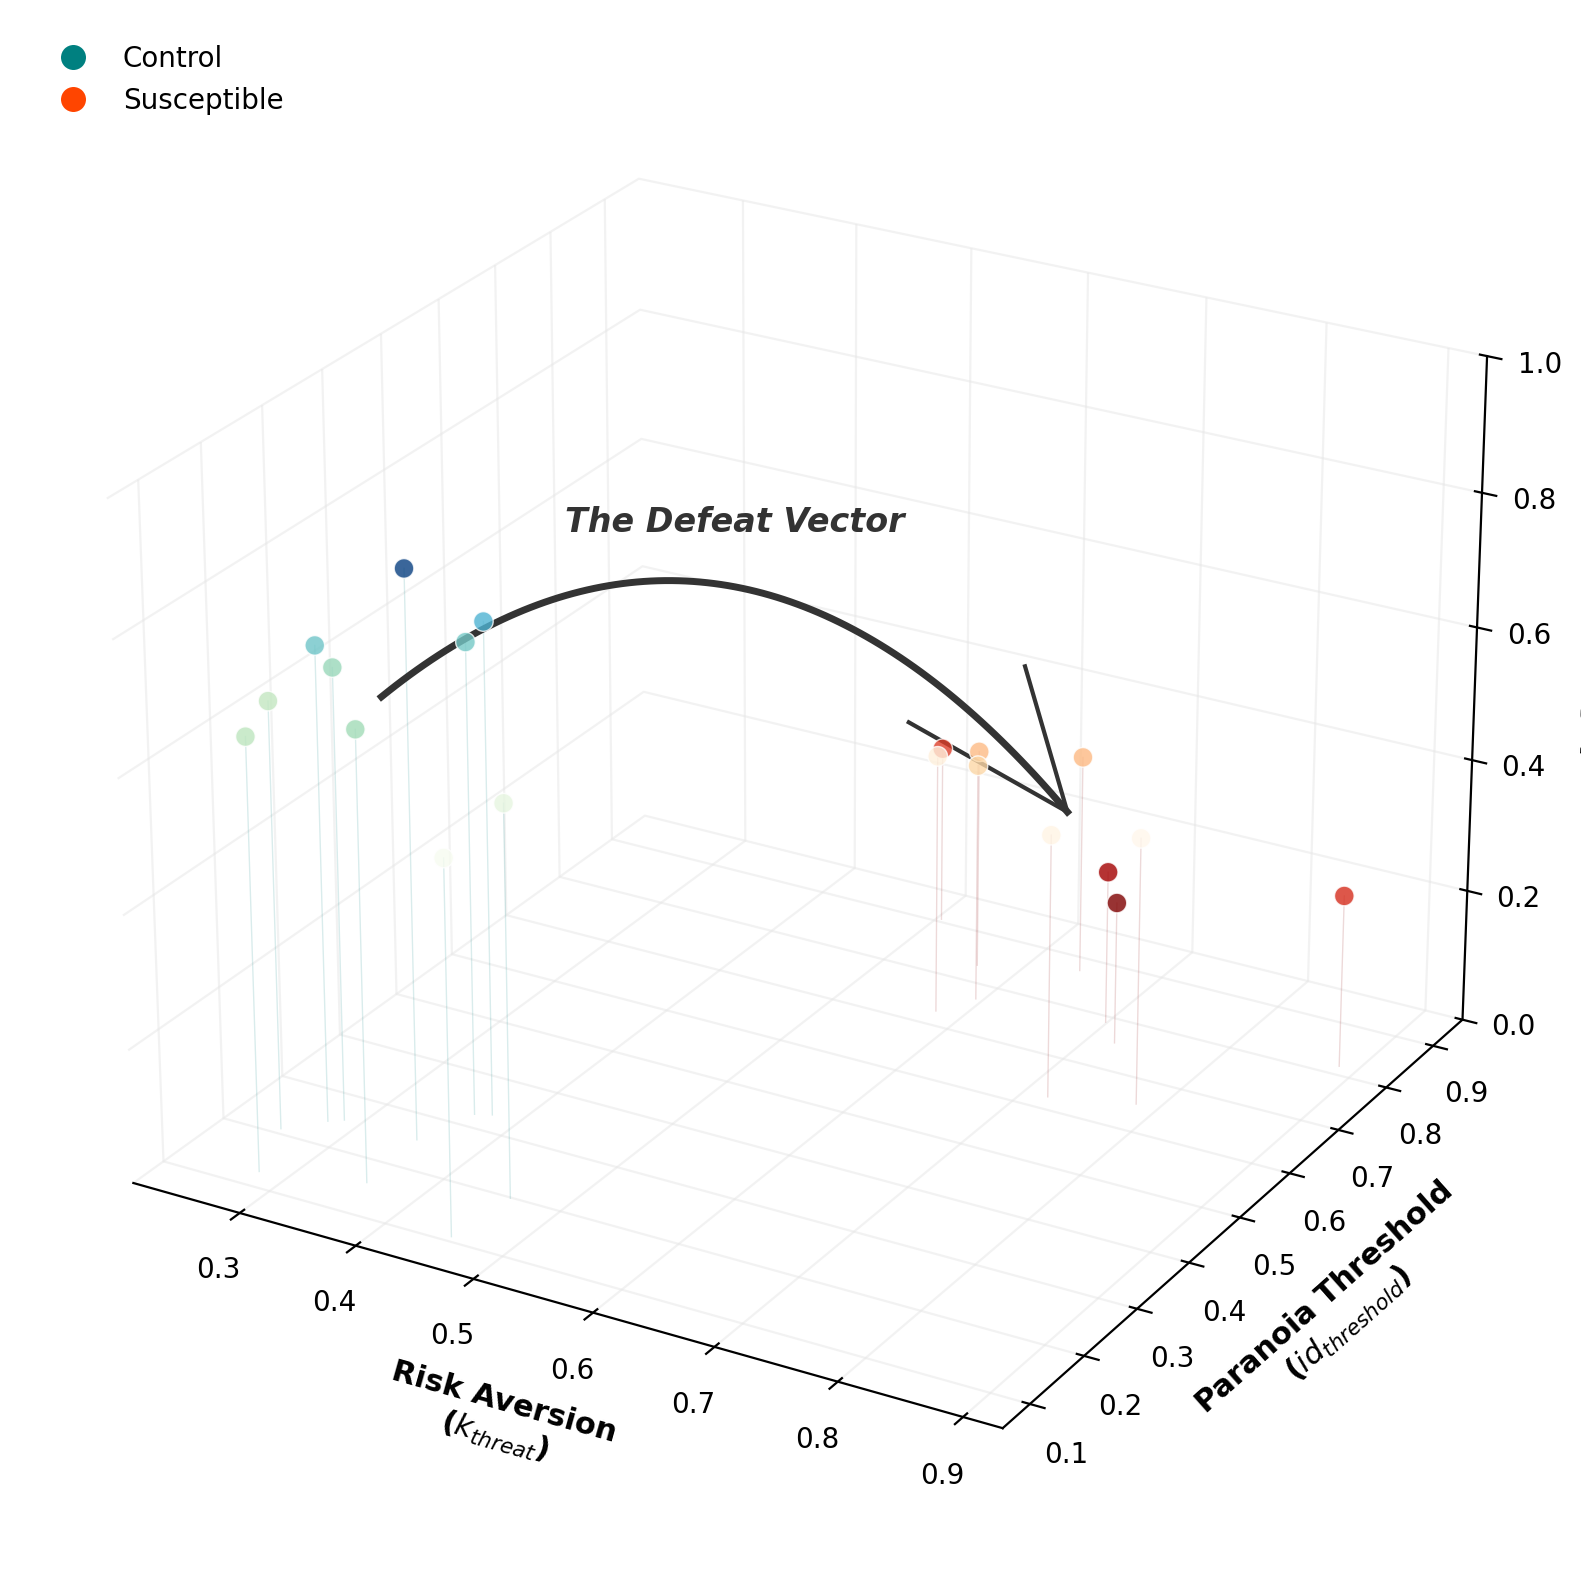

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_bezier_curve(p0, p1, p2, num_points=100):
    t = np.linspace(0, 1, num_points)[:, np.newaxis]
    curve = (1 - t)**2 * p0 + 2 * (1 - t) * t * p1 + t**2 * p2
    return curve[:, 0], curve[:, 1], curve[:, 2]

# --- 1. GENERATE DUMMY DATA ---
np.random.seed(42)
n_points = 10

# Control (High Info Gain, Low Paranoia)
ctrl_x = np.random.normal(0.3, 0.1, n_points) 
ctrl_y = np.random.normal(0.3, 0.1, n_points)
ctrl_z = np.random.normal(0.7, 0.1, n_points)

# Susceptible (Low Info Gain, High Paranoia)
susp_x = np.random.normal(0.7, 0.1, n_points)
susp_y = np.random.normal(0.8, 0.1, n_points)
susp_z = np.random.normal(0.3, 0.1, n_points)

# --- 2. CALCULATE GEOMETRY ---
c_start = np.array([np.mean(ctrl_x), np.mean(ctrl_y), np.mean(ctrl_z)])
c_end   = np.array([np.mean(susp_x), np.mean(susp_y), np.mean(susp_z)])

# Arch logic
midpoint = (c_start + c_end) / 2
control_point = midpoint + np.array([0, 0, 0.5]) # Lifts the arrow arch up
lx, ly, lz = get_bezier_curve(c_start, control_point, c_end)

# --- 3. STYLISH PLOTTING ---
fig = plt.figure(figsize=(10, 8), dpi=200) # High DPI
ax = fig.add_subplot(111, projection='3d')

# A. THE DROP LINES (The "Pro" Touch)
# We find the floor (z_min) to anchor our lines
z_min = 0.0
for x, y, z in zip(ctrl_x, ctrl_y, ctrl_z):
    ax.plot([x, x], [y, y], [z_min, z], color='teal', alpha=0.15, linewidth=0.5)
for x, y, z in zip(susp_x, susp_y, susp_z):
    ax.plot([x, x], [y, y], [z_min, z], color='darkred', alpha=0.15, linewidth=0.5)

# B. THE CLOUDS (Gradient Colors)
# Control: Map Z values to a "Cool" colormap (Teals)
sc1 = ax.scatter(ctrl_x, ctrl_y, ctrl_z, c=ctrl_z, cmap='GnBu', 
                 s=50, alpha=0.8, edgecolors='white', linewidth=0.5, label='Control')

# Susceptible: Map Z values to a "Warm" colormap (Oranges/Reds)
sc2 = ax.scatter(susp_x, susp_y, susp_z, c=susp_z, cmap='OrRd_r', 
                 s=50, alpha=0.8, edgecolors='white', linewidth=0.5, label='Susceptible')

# C. THE DEFEAT VECTOR (Styled)
ax.plot(lx, ly, lz, color='#333333', linewidth=2.5, linestyle='-')

# Arrow Head
direction = np.array([lx[-1] - lx[-2], ly[-1] - ly[-2], lz[-1] - lz[-2]])
length = np.linalg.norm(direction)
direction = direction / length 
ax.quiver(lx[-1], ly[-1], lz[-1], 
          direction[0], direction[1], direction[2], 
          length=0.08, color='#333333', arrow_length_ratio=3, pivot='tip', linewidth=1.5)

# D. AESTHETICS CLEANUP
# Remove gray panes for a clean "white paper" look
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Lighter grid
ax.xaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
ax.yaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
ax.zaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)

# Labels with Math Formatting
ax.set_xlabel('Risk Aversion\n($k_{threat}$)', fontsize=11, weight='bold', labelpad=10)
ax.set_ylabel('Paranoia Threshold\n($id_{threshold}$)', fontsize=11, weight='bold', labelpad=10)
ax.set_zlabel('Info Gain\n(slope)', fontsize=11, weight='bold', labelpad=10)

# Set limits to make sure the floor lines touch the bottom
ax.set_zlim(z_min, 1.0)

# Add label for the vector
ax.text(lx[50], ly[50], lz[50] + 0.08, "The Defeat Vector", 
        color='#333333', fontsize=12, style='italic', ha='center', weight='bold')

# Legend (Manually creating proxy artists to represent the groups generally)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Control',
                          markerfacecolor='teal', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Susceptible',
                          markerfacecolor='orangered', markersize=10)]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2601/818045864.py:26: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')


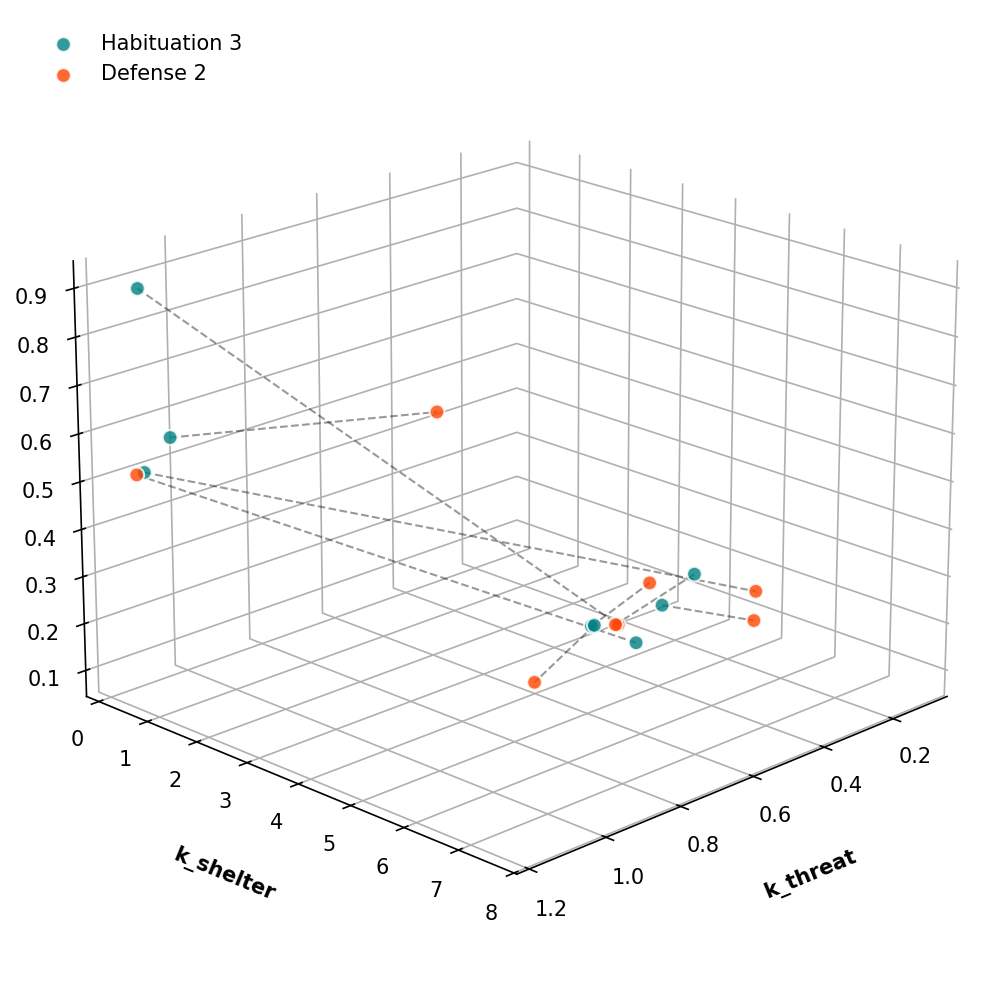

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import io

# --- 1. DATA PREPARATION ---
sim_txt = """Name param_id_threshold param_sensory_prec_slope param_k_shelter param_k_threat param_delta_stay metric_entropy metric_n_ch_co metric_n_co_ch metric_n_co_sh metric_n_sh_co metric_t_investigating metric_t_shelter metric_laziness
LOSS_13_def2 0.515727116 0.816352739 0.298897194 1.155770898 1.009888668 4.296422916 15 15 8 9 0.1535 0.3055 0.7375
LOSS_13_hab3 0.147982637 0.087463598 4.908866188 0.450585783 3.754876603 3.195065402 11 11 6 6 0.2345 0.5965 0.8335
LOSS_14_def2 0.15 0.15 3.5 0.2 3 4.43724739 24 25 7 8 0.497 0.1705 0.6675
LOSS_14_hab3 0.215362591 0.081368589 4.858386478 0.568861431 5.207956288 2.554980742 10 11 5 6 0.173 0.6515 0.8475
LOSS_15_def2 0.101950405 0.055407017 4.950524614 0.115140038 3.154707234 2.940415636 13 13 5 5 0.1795 0.5335 0.7985
LOSS_15_hab3 0.210223671 0.066467643 4.937115452 0.381617244 3.898368379 3.092608564 8 9 3 4 0.207 0.624 0.8445
LOSS_16_def2 0.367263922 0.63 7.521287655 1.110292279 2.016434895 1.930290098 5 5 1 2 0.0675 0.725 0.9115
LOSS_16_hab3 0.219379437 0.073756821 4.914607524 0.569200004 3.918470286 2.602157206 7 8 4 5 0.2735 0.5845 0.8865
LOSS_17_def2 0.202312574 0.066042002 4.89559458 0.50699334 4.360236213 2.707225653 5 5 2 2 0.1385 0.724 0.896
LOSS_17_hab3 0.246993298 0.048389916 4.886265037 0.281803009 3.906165009 3.79658214 17 17 7 7 0.3635 0.4055 0.7745
LOSS_18_def2 0.199185522 0.08669176 4.886347125 0.498324589 4.642227045 3.41889804 13 14 4 5 0.2 0.548 0.785
LOSS_18_hab3 0.897602032 0.886823797 0.303039948 1.142265274 1.01261406 4.71291424 14 15 11 12 0.229 0.3405 0.6965
LOSS_19_def2 0.168056683 0.057470287 4.989673124 0.117175169 2.559438887 3.813127568 14 15 7 8 0.249 0.457 0.7605
LOSS_19_hab3 0.513798117 0.87705756 0.271078611 1.133015332 1.060739951 4.666456582 11 12 7 8 0.1535 0.228 0.7555
LOSS_20_def2 0.474978537 0.719183635 0.735021943 0.40967481 2.775568426 3.901667725 13 14 4 5 0.3685 0.228 0.8085
LOSS_20_hab3 0.600207615 0.768483092 0.720644735 1.120970781 2.314835569 4.395300543 12 12 7 8 0.195 0.221 0.756"""

df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')
df['mouse_id'] = df['Name'].apply(lambda x: x.split('_')[1])
df['phase'] = df['Name'].apply(lambda x: x.split('_')[2])

# --- 2. PLOTTING ---
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# Axes parameters
px, py, pz = 'param_k_threat', 'param_k_shelter', 'param_id_threshold'

# Plot transitions for each mouse
mouse_list = df['mouse_id'].unique()

for m_id in mouse_list:
    m_data = df[df['mouse_id'] == m_id]
    
    # Ensure we have both phases for the line
    if len(m_data) == 2:
        h_row = m_data[m_data['phase'] == 'hab3']
        d_row = m_data[m_data['phase'] == 'def2']
        
        # Draw line connecting hab3 to def2
        ax.plot(
            [h_row[px].values[0], d_row[px].values[0]],
            [h_row[py].values[0], d_row[py].values[0]],
            [h_row[pz].values[0], d_row[pz].values[0]],
            color='black', linewidth=1, alpha=0.4, linestyle='--'
        )

# Scatter plot for points
hab = df[df['phase'] == 'hab3']
def2 = df[df['phase'] == 'def2']

ax.scatter(hab[px], hab[py], hab[pz], color='teal', s=50, alpha=0.8, edgecolors='w', label='Pre-defeat')
ax.scatter(def2[px], def2[py], def2[pz], color='orangered', s=50, alpha=0.8, edgecolors='w', label='Post-defeat')

# Aesthetics cleanup
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.set_xlabel('k_threat', fontsize=10, weight='bold', labelpad=15) # Increased padding
ax.set_ylabel('k_shelter', fontsize=10, weight='bold', labelpad=15)
ax.set_zlabel('id_threshold', fontsize=10, weight='bold', labelpad=15)

ax.legend(loc='upper left', frameon=False)
ax.view_init(elev=20, azim=45)

plt.subplots_adjust(left=0.15, right=0.95, bottom=0.1, top=0.9)
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2601/2939247424.py:27: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')


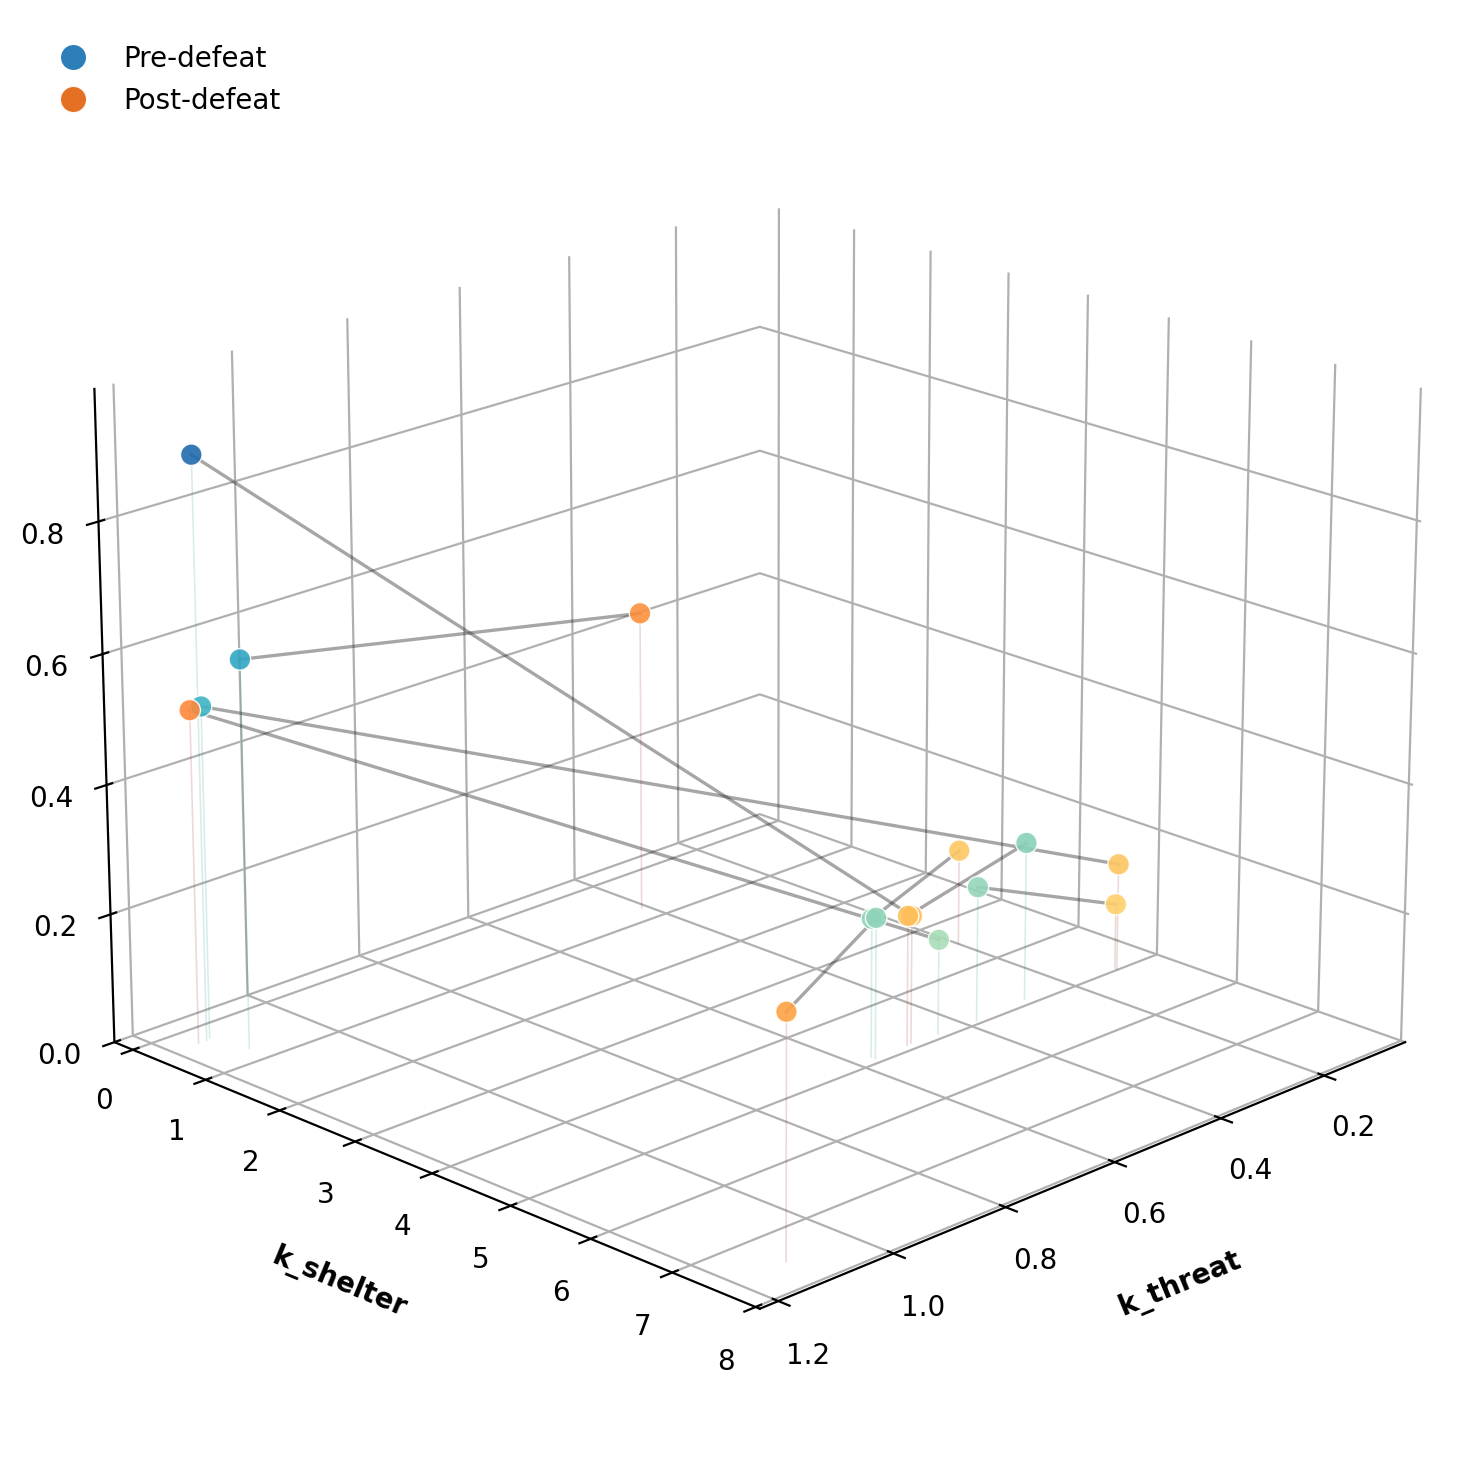

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import io
from matplotlib.lines import Line2D

# --- 1. DATA PREPARATION ---
sim_txt = """Name param_id_threshold param_sensory_prec_slope param_k_shelter param_k_threat param_delta_stay metric_entropy metric_n_ch_co metric_n_co_ch metric_n_co_sh metric_n_sh_co metric_t_investigating metric_t_shelter metric_laziness
LOSS_13_def2 0.515727116 0.816352739 0.298897194 1.155770898 1.009888668 4.296422916 15 15 8 9 0.1535 0.3055 0.7375
LOSS_13_hab3 0.147982637 0.087463598 4.908866188 0.450585783 3.754876603 3.195065402 11 11 6 6 0.2345 0.5965 0.8335
LOSS_14_def2 0.15 0.15 3.5 0.2 3 4.43724739 24 25 7 8 0.497 0.1705 0.6675
LOSS_14_hab3 0.215362591 0.081368589 4.858386478 0.568861431 5.207956288 2.554980742 10 11 5 6 0.173 0.6515 0.8475
LOSS_15_def2 0.101950405 0.055407017 4.950524614 0.115140038 3.154707234 2.940415636 13 13 5 5 0.1795 0.5335 0.7985
LOSS_15_hab3 0.210223671 0.066467643 4.937115452 0.381617244 3.898368379 3.092608564 8 9 3 4 0.207 0.624 0.8445
LOSS_16_def2 0.367263922 0.63 7.521287655 1.110292279 2.016434895 1.930290098 5 5 1 2 0.0675 0.725 0.9115
LOSS_16_hab3 0.219379437 0.073756821 4.914607524 0.569200004 3.918470286 2.602157206 7 8 4 5 0.2735 0.5845 0.8865
LOSS_17_def2 0.202312574 0.066042002 4.89559458 0.50699334 4.360236213 2.707225653 5 5 2 2 0.1385 0.724 0.896
LOSS_17_hab3 0.246993298 0.048389916 4.886265037 0.281803009 3.906165009 3.79658214 17 17 7 7 0.3635 0.4055 0.7745
LOSS_18_def2 0.199185522 0.08669176 4.886347125 0.498324589 4.642227045 3.41889804 13 14 4 5 0.2 0.548 0.785
LOSS_18_hab3 0.897602032 0.886823797 0.303039948 1.142265274 1.01261406 4.71291424 14 15 11 12 0.229 0.3405 0.6965
LOSS_19_def2 0.168056683 0.057470287 4.989673124 0.117175169 2.559438887 3.813127568 14 15 7 8 0.249 0.457 0.7605
LOSS_19_hab3 0.513798117 0.87705756 0.271078611 1.133015332 1.060739951 4.666456582 11 12 7 8 0.1535 0.228 0.7555
LOSS_20_def2 0.474978537 0.719183635 0.735021943 0.40967481 2.775568426 3.901667725 13 14 4 5 0.3685 0.228 0.8085
LOSS_20_hab3 0.600207615 0.768483092 0.720644735 1.120970781 2.314835569 4.395300543 12 12 7 8 0.195 0.221 0.756"""

df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')
df['mouse_id'] = df['Name'].apply(lambda x: x.split('_')[1])
df['phase'] = df['Name'].apply(lambda x: x.split('_')[2])

# Params
px, py, pz = 'param_k_threat', 'param_k_shelter', 'param_id_threshold'

# --- 2. PLOTTING ---
fig = plt.figure(figsize=(10, 8), dpi=200)
ax = fig.add_subplot(111, projection='3d')
z_min = 0.0

# Mouse Pairing Lines
mouse_list = df['mouse_id'].unique()
for m_id in mouse_list:
    m_data = df[df['mouse_id'] == m_id]
    if len(m_data) == 2:
        h = m_data[m_data['phase'] == 'hab3']
        d = m_data[m_data['phase'] == 'def2']
        
        # Phase connection line (slightly darker for visibility)
        ax.plot([h[px].item(), d[px].item()],
                [h[py].item(), d[py].item()],
                [h[pz].item(), d[pz].item()],
                color='#222222', linewidth=1.2, alpha=0.4, zorder=1)
        
        # Drop lines to floor
        ax.plot([h[px].item(), h[px].item()], [h[py].item(), h[py].item()], [z_min, h[pz].item()], 
                color='teal', alpha=0.15, linewidth=0.6)
        ax.plot([d[px].item(), d[px].item()], [d[py].item(), d[py].item()], [z_min, d[pz].item()], 
                color='darkred', alpha=0.15, linewidth=0.6)

# Scatter with Tighter Colormaps
hab = df[df['phase'] == 'hab3']
def2 = df[df['phase'] == 'def2']

# Define 'tight' limits for the colormap to avoid the white/black extremes
# Adjusting vmin/vmax to be slightly outside the data range creates a "mid-tone" saturated look
z_all = df[pz].values
z_range_min, z_range_max = np.min(z_all), np.max(z_all)
v_min = z_range_min - 0.5 
v_max = z_range_max + 0.5

sc1 = ax.scatter(hab[px], hab[py], hab[pz], c=hab[pz], cmap='YlGnBu', 
                 vmin=v_min, vmax=v_max, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)
sc2 = ax.scatter(def2[px], def2[py], def2[pz], c=def2[pz], cmap='YlOrRd', 
                 vmin=v_min, vmax=v_max, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)

# Aesthetics
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.set_xlabel('k_threat', fontsize=10, weight='bold', labelpad=12)
ax.set_ylabel('k_shelter', fontsize=10, weight='bold', labelpad=12)
ax.set_zlabel('id_threshold', fontsize=10, weight='bold', labelpad=12)

ax.set_zlim(z_min, z_range_max + 0.1)
ax.dist = 11 
ax.view_init(elev=20, azim=45)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Pre-defeat', markerfacecolor='#2c7fb8', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Post-defeat', markerfacecolor="#e36a1af5", markersize=10)
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2601/2336566022.py:28: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')


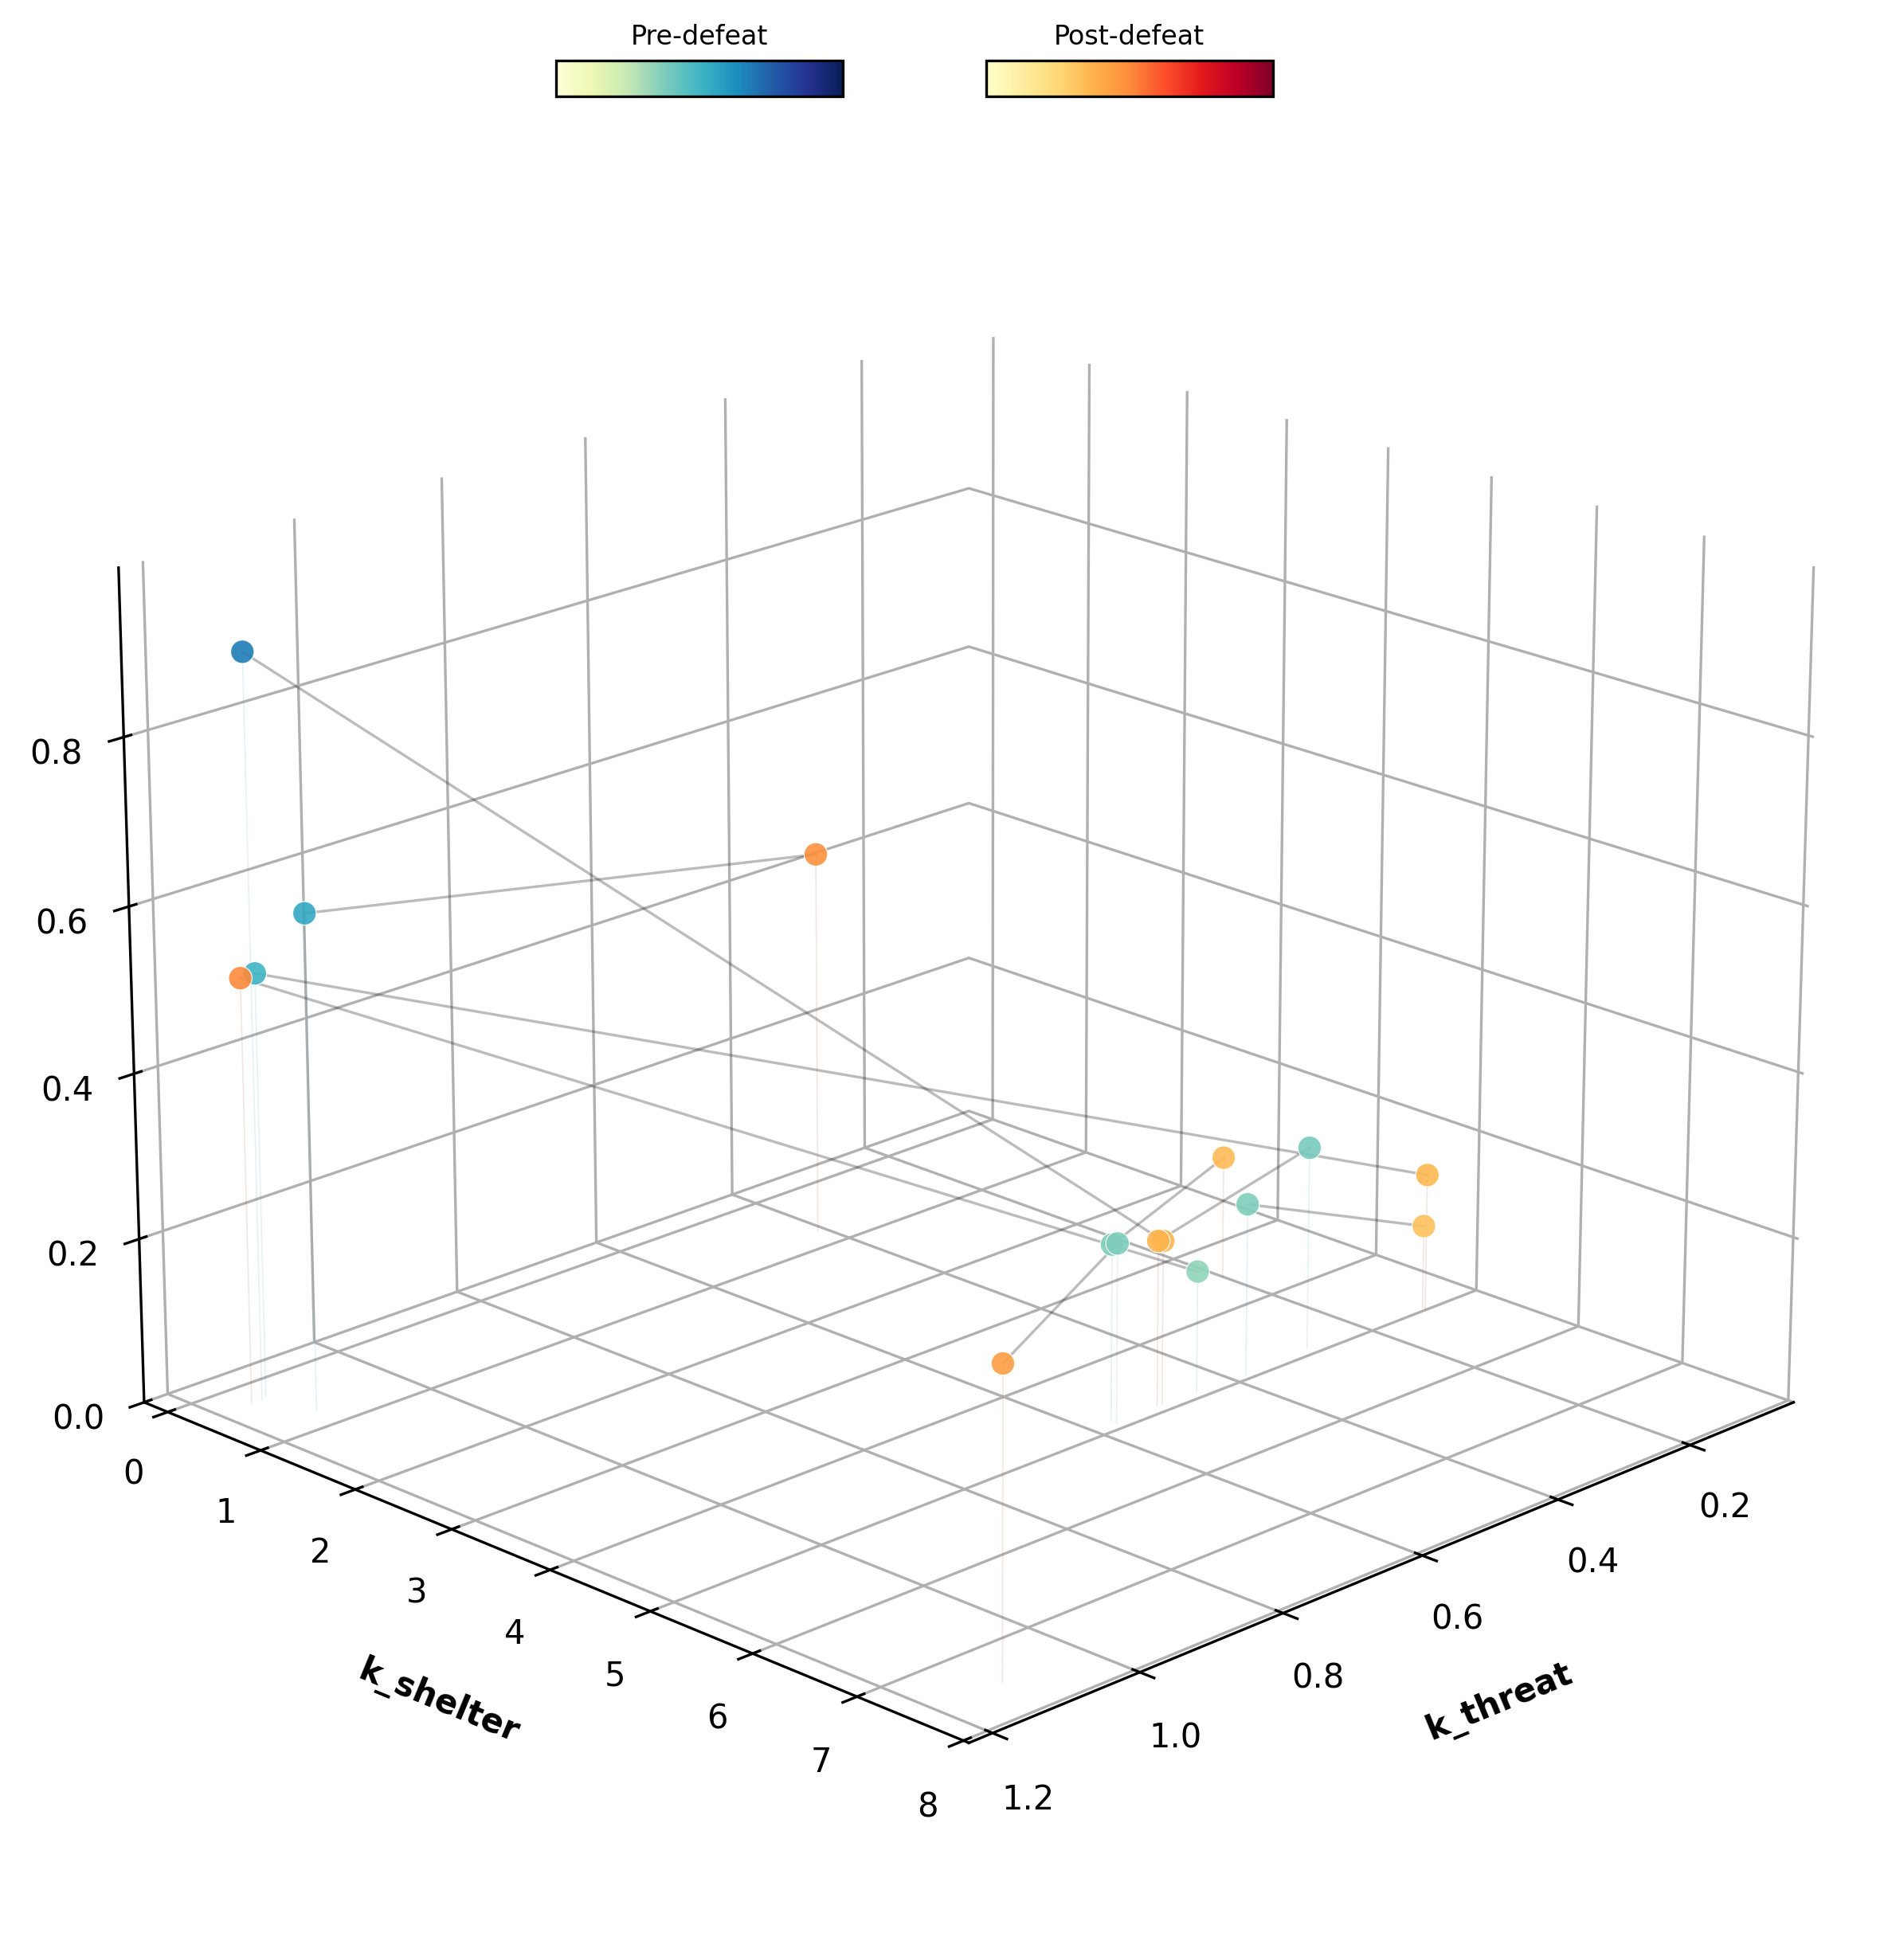

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import io
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# --- 1. DATA PREPARATION ---
sim_txt = """Name param_id_threshold param_sensory_prec_slope param_k_shelter param_k_threat param_delta_stay metric_entropy metric_n_ch_co metric_n_co_ch metric_n_co_sh metric_n_sh_co metric_t_investigating metric_t_shelter metric_laziness
LOSS_13_def2 0.515727116 0.816352739 0.298897194 1.155770898 1.009888668 4.296422916 15 15 8 9 0.1535 0.3055 0.7375
LOSS_13_hab3 0.147982637 0.087463598 4.908866188 0.450585783 3.754876603 3.195065402 11 11 6 6 0.2345 0.5965 0.8335
LOSS_14_def2 0.15 0.15 3.5 0.2 3 4.43724739 24 25 7 8 0.497 0.1705 0.6675
LOSS_14_hab3 0.215362591 0.081368589 4.858386478 0.568861431 5.207956288 2.554980742 10 11 5 6 0.173 0.6515 0.8475
LOSS_15_def2 0.101950405 0.055407017 4.950524614 0.115140038 3.154707234 2.940415636 13 13 5 5 0.1795 0.5335 0.7985
LOSS_15_hab3 0.210223671 0.066467643 4.937115452 0.381617244 3.898368379 3.092608564 8 9 3 4 0.207 0.624 0.8445
LOSS_16_def2 0.367263922 0.63 7.521287655 1.110292279 2.016434895 1.930290098 5 5 1 2 0.0675 0.725 0.9115
LOSS_16_hab3 0.219379437 0.073756821 4.914607524 0.569200004 3.918470286 2.602157206 7 8 4 5 0.2735 0.5845 0.8865
LOSS_17_def2 0.202312574 0.066042002 4.89559458 0.50699334 4.360236213 2.707225653 5 5 2 2 0.1385 0.724 0.896
LOSS_17_hab3 0.246993298 0.048389916 4.886265037 0.281803009 3.906165009 3.79658214 17 17 7 7 0.3635 0.4055 0.7745
LOSS_18_def2 0.199185522 0.08669176 4.886347125 0.498324589 4.642227045 3.41889804 13 14 4 5 0.2 0.548 0.785
LOSS_18_hab3 0.897602032 0.886823797 0.303039948 1.142265274 1.01261406 4.71291424 14 15 11 12 0.229 0.3405 0.6965
LOSS_19_def2 0.168056683 0.057470287 4.989673124 0.117175169 2.559438887 3.813127568 14 15 7 8 0.249 0.457 0.7605
LOSS_19_hab3 0.513798117 0.87705756 0.271078611 1.133015332 1.060739951 4.666456582 11 12 7 8 0.1535 0.228 0.7555
LOSS_20_def2 0.474978537 0.719183635 0.735021943 0.40967481 2.775568426 3.901667725 13 14 4 5 0.3685 0.228 0.8085
LOSS_20_hab3 0.600207615 0.768483092 0.720644735 1.120970781 2.314835569 4.395300543 12 12 7 8 0.195 0.221 0.756"""

df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')
df['mouse_id'] = df['Name'].apply(lambda x: x.split('_')[1])
df['phase'] = df['Name'].apply(lambda x: x.split('_')[2])

# Params
px, py, pz = 'param_k_threat', 'param_k_shelter', 'param_id_threshold'

# --- 2. PLOTTING ---
fig = plt.figure(figsize=(10, 10), dpi=300)
ax = fig.add_subplot(111, projection='3d')
z_min = 0.0

# Mouse Pairing Lines
mouse_list = df['mouse_id'].unique()
for m_id in mouse_list:
    m_data = df[df['mouse_id'] == m_id]
    if len(m_data) == 2:
        h = m_data[m_data['phase'] == 'hab3']
        d = m_data[m_data['phase'] == 'def2']
        ax.plot([h[px].item(), d[px].item()], [h[py].item(), d[py].item()], [h[pz].item(), d[pz].item()],
                color='#222222', linewidth=0.8, alpha=0.3)
        ax.plot([h[px].item(), h[px].item()], [h[py].item(), h[py].item()], [z_min, h[pz].item()], 
                color='teal', alpha=0.1, linewidth=0.4)
        ax.plot([d[px].item(), d[px].item()], [d[py].item(), d[py].item()], [z_min, d[pz].item()], 
                color='darkred', alpha=0.1, linewidth=0.4)

# Normalization for Colorbars
z_all = df[pz].values
v_min, v_max = np.min(z_all) - 0.75, np.max(z_all) + 0.75
norm = Normalize(vmin=v_min, vmax=v_max)

# Scatter
hab = df[df['phase'] == 'hab3']
def2 = df[df['phase'] == 'def2']

cmap_pre = plt.get_cmap('YlGnBu')
cmap_post = plt.get_cmap('YlOrRd')

ax.scatter(hab[px], hab[py], hab[pz], c=hab[pz], cmap=cmap_pre, norm=norm, s=50, alpha=0.9, edgecolors='white', linewidth=0.3)
ax.scatter(def2[px], def2[py], def2[pz], c=def2[pz], cmap=cmap_post, norm=norm, s=50, alpha=0.9, edgecolors='white', linewidth=0.3)

# Aesthetics
ax.set_xlabel('k_threat', fontsize=10, weight='bold', labelpad=12)
ax.set_ylabel('k_shelter', fontsize=10, weight='bold', labelpad=12)
ax.set_zlabel('id_threshold', fontsize=10, weight='bold', labelpad=12)
ax.set_zlim(z_min, np.max(z_all) + 0.1)
ax.dist = 11 
ax.view_init(elev=20, azim=45)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# --- SIDE-BY-SIDE MINI COLORBARS AT TOP ---
# Format: [left, bottom, width, height]
cax1 = fig.add_axes([0.35, 0.88, 0.12, 0.015]) 
cax2 = fig.add_axes([0.53, 0.88, 0.12, 0.015])

sm_pre = ScalarMappable(norm=norm, cmap=cmap_pre)
cbar1 = fig.colorbar(sm_pre, cax=cax1, orientation='horizontal')
cbar1.set_ticks([])
cax1.set_title('Pre-defeat', weight='normal', size=8, pad=5)

sm_post = ScalarMappable(norm=norm, cmap=cmap_post)
cbar2 = fig.colorbar(sm_post, cax=cax2, orientation='horizontal')
cbar2.set_ticks([])
cax2.set_title('Post-defeat', weight='normal', size=8, pad=5)

plt.show()

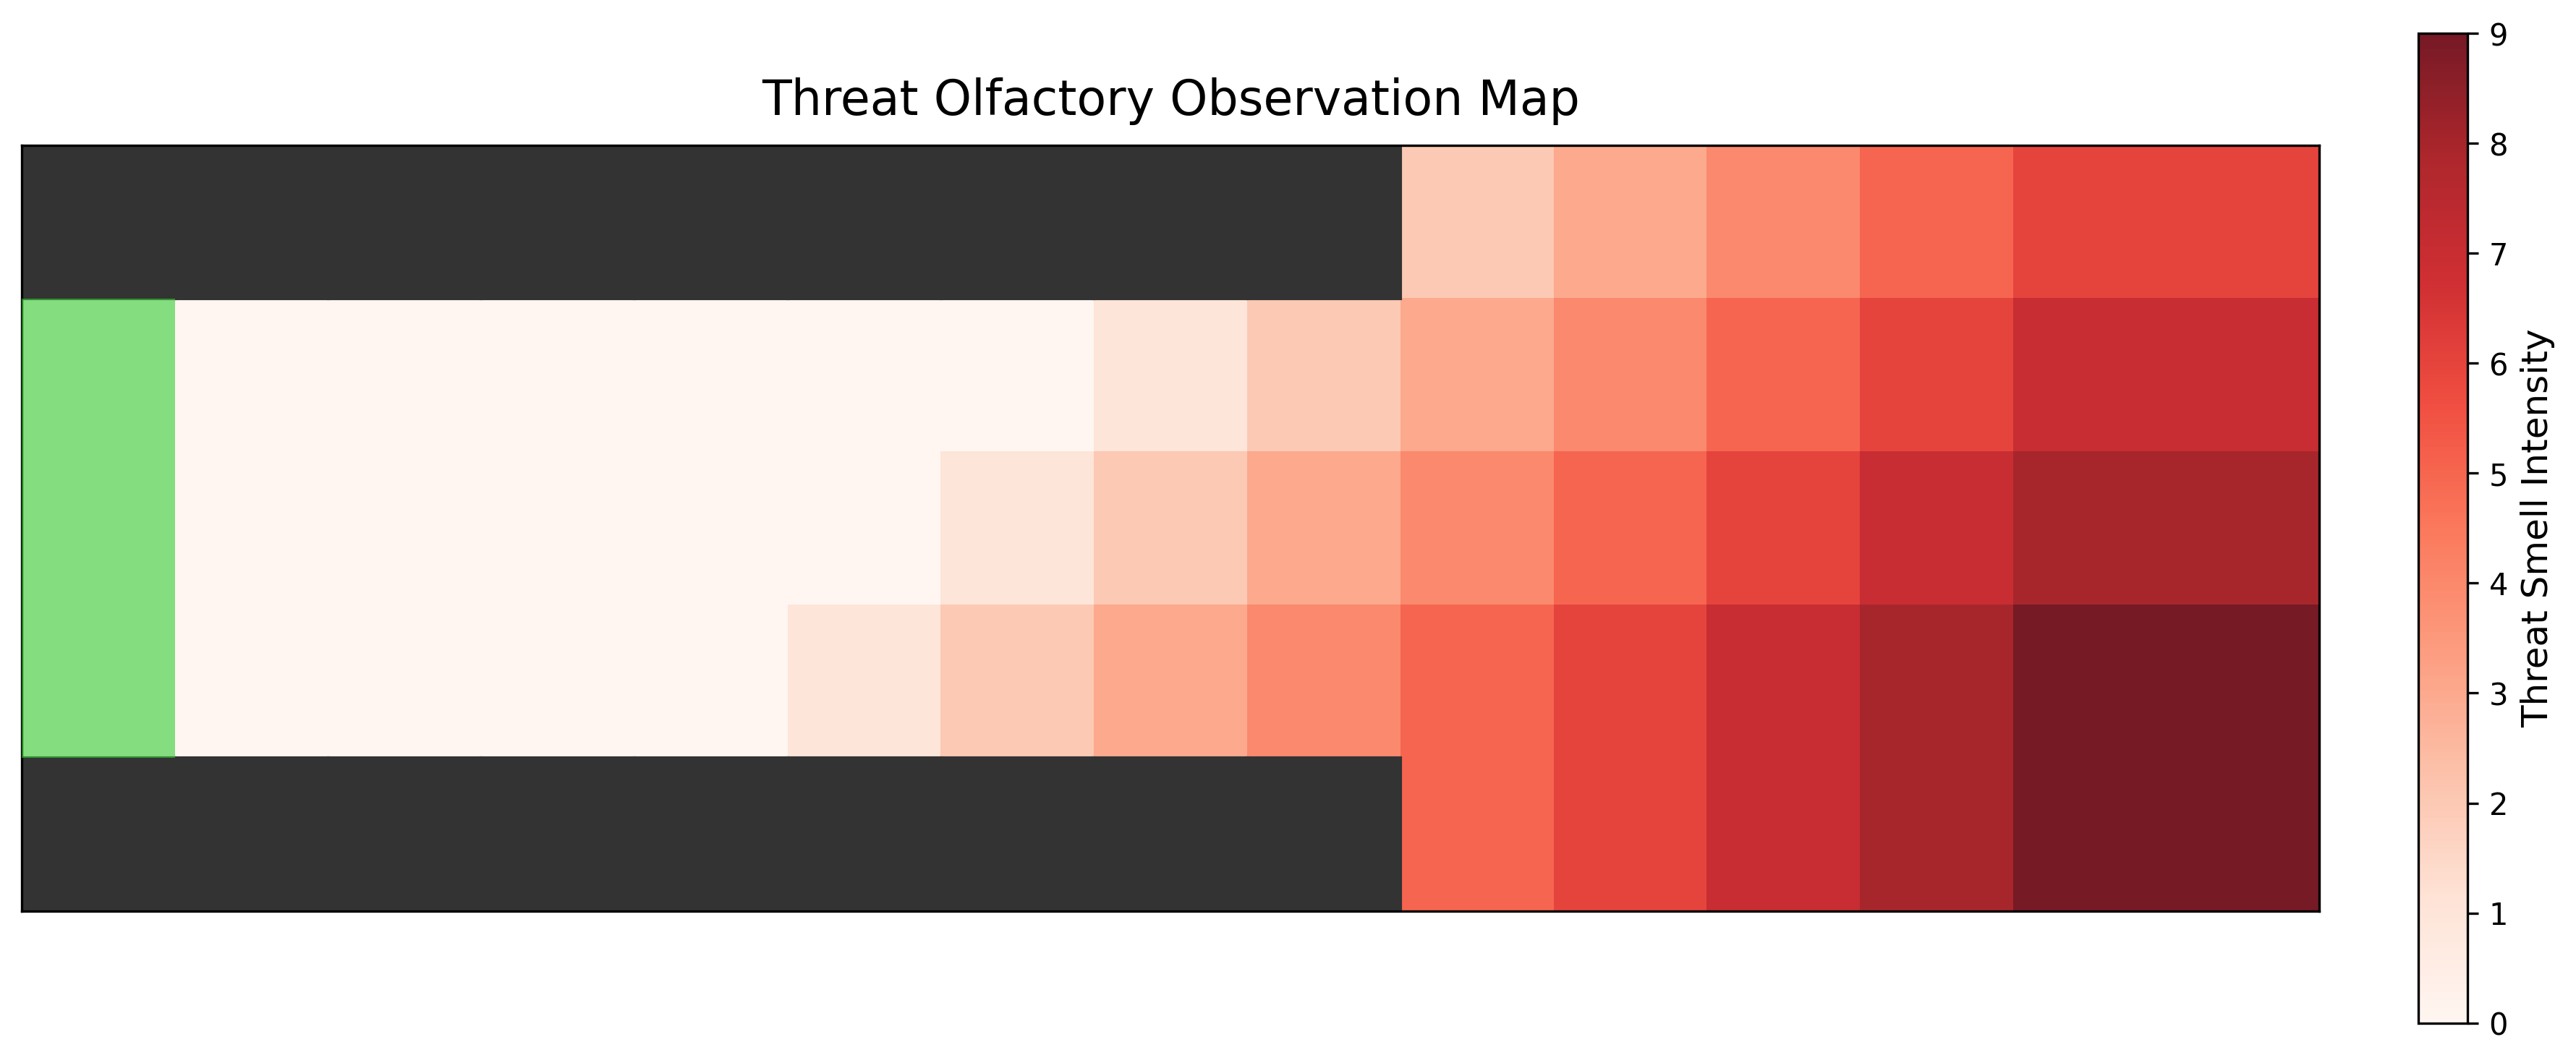

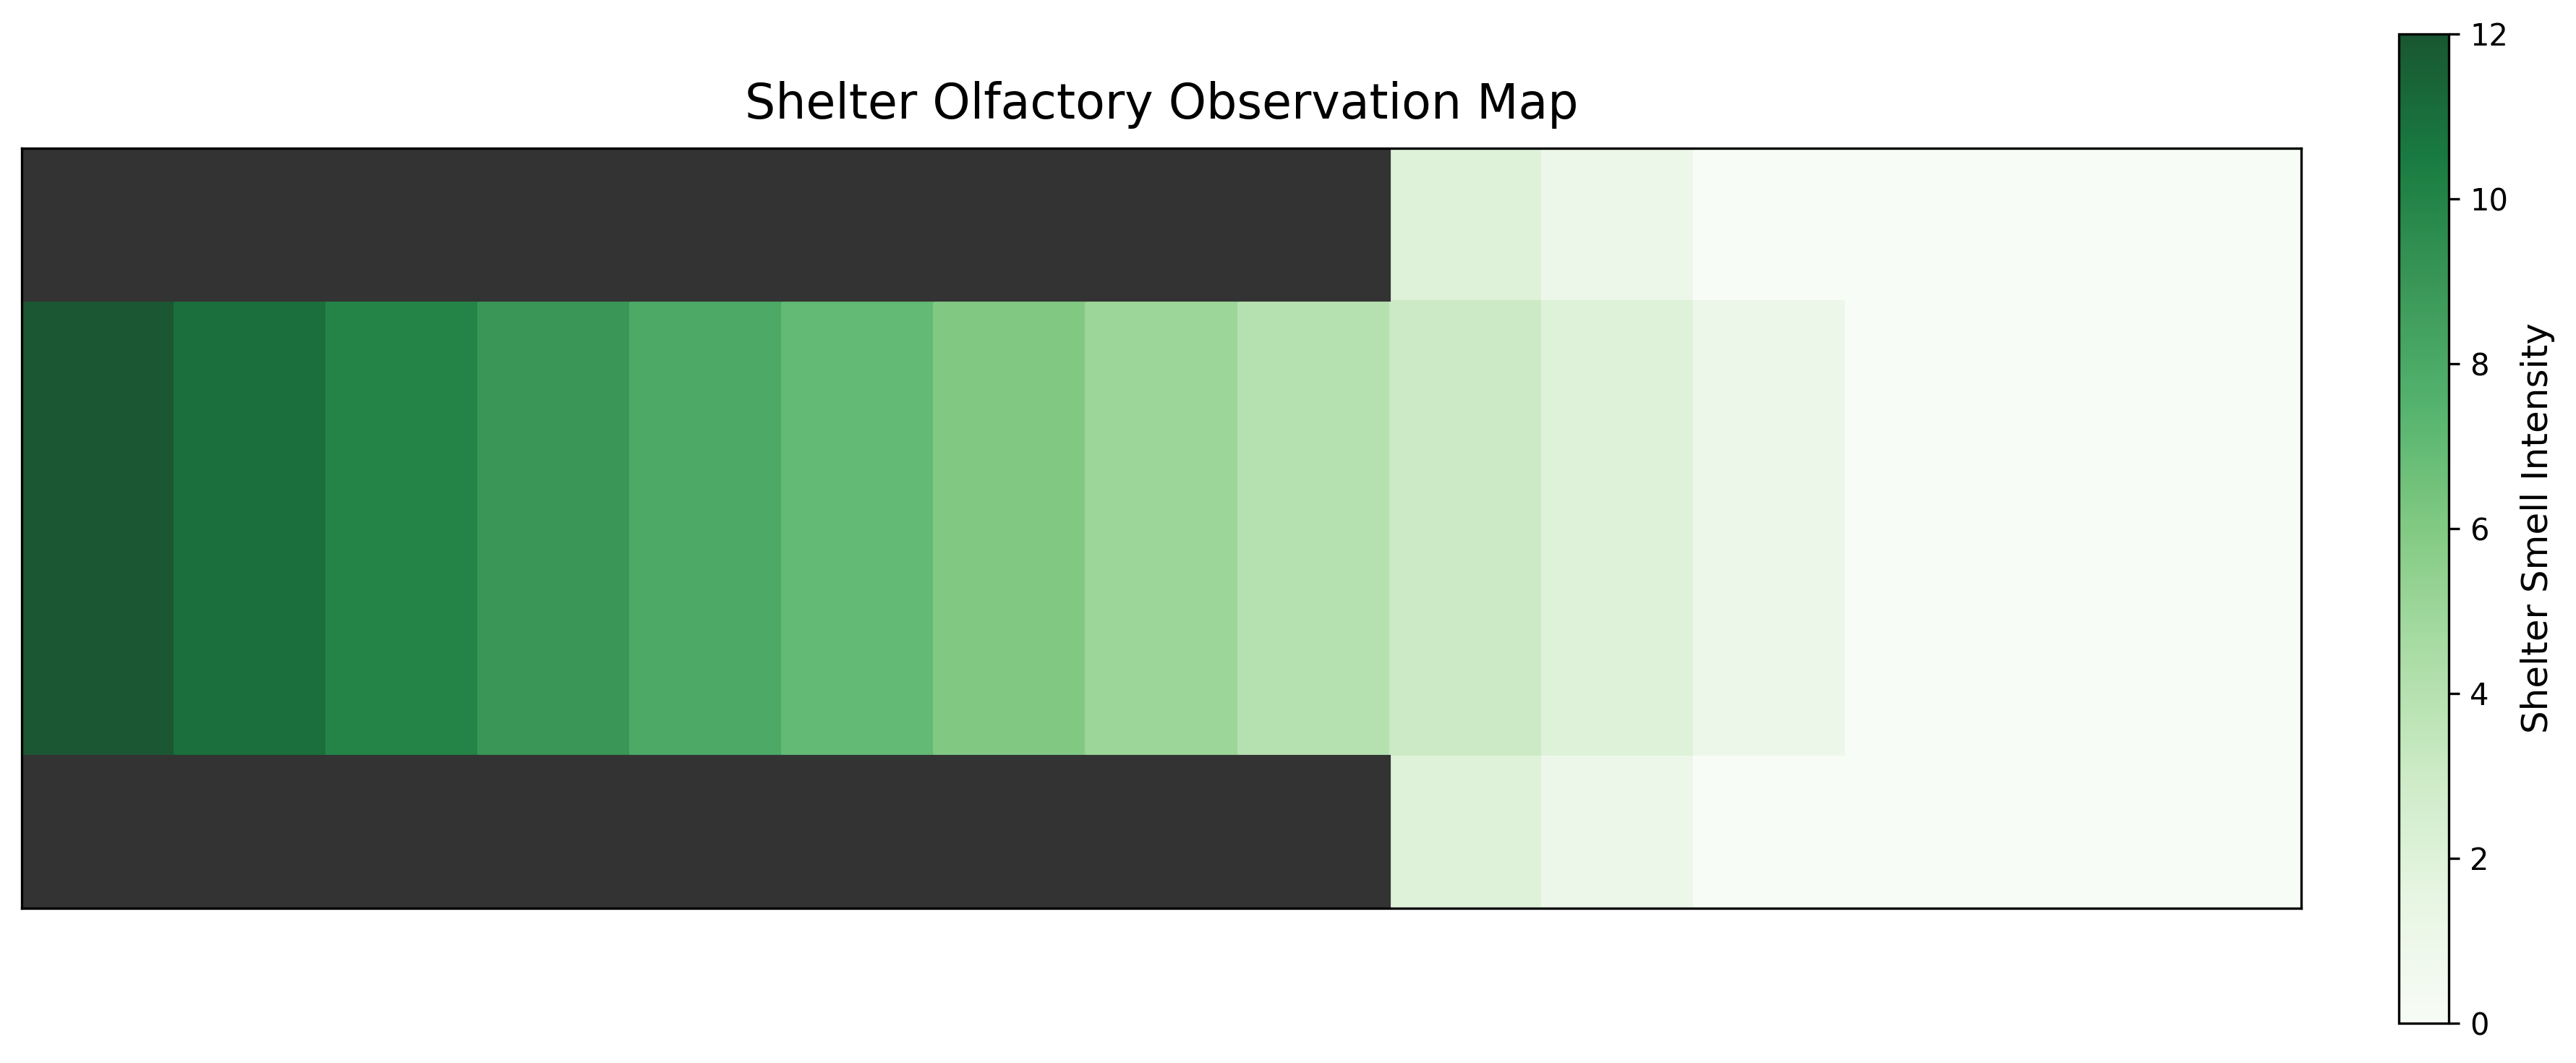

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- 1. SETUP DATA ---
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

rows, cols = mask.shape

# Sources
shelter_cells = [(r, 0) for r in range(rows) if mask[r, 0]]
threat_cells = [(3, 13), (3, 14), (4, 13), (4, 14)]

# Compute Distances
def get_min_manhattan_dist(r, c, source_cells):
    dists = [abs(r - sr) + abs(c - sc) for (sr, sc) in source_cells]
    return min(dists)

grid_threat = np.full((rows, cols), np.nan)
grid_shelter = np.full((rows, cols), np.nan)

max_threat_intensity = 9
max_shelter_intensity = 12

for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            # Threat
            dist_t = get_min_manhattan_dist(r, c, threat_cells)
            grid_threat[r, c] = max(0, max_threat_intensity - dist_t)
            
            # Shelter
            dist_s = get_min_manhattan_dist(r, c, shelter_cells)
            grid_shelter[r, c] = max(0, max_shelter_intensity - dist_s)

# Helper for consistent styling
def setup_plot_ax(ax, rows, cols, mask):
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    # Draw walls
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c]:
                ax.add_patch(Rectangle((c-0.5, r-0.5), 1, 1, color=(0.2, 0.2, 0.2)))

# --- 2. PLOT 1: THREAT INTENSITY ---
fig1, ax1 = plt.subplots(figsize=(12, 5), dpi=300) # High Res
setup_plot_ax(ax1, rows, cols, mask)

# Heatmap
im1 = ax1.imshow(grid_threat, cmap='Reds', alpha=0.9, vmin=0, vmax=max_threat_intensity)
cbar1 = fig1.colorbar(im1, ax=ax1, fraction=0.03, pad=0.04)
cbar1.set_label('Threat Smell Intensity', fontsize=12)
cbar1.ax.tick_params(labelsize=10)

# Overlay Shelter Location (Green) for context
for (sr, sc) in shelter_cells:
    ax1.add_patch(Rectangle((sc - 0.5, sr - 0.5), 1, 1, 
                            linewidth=0, facecolor='limegreen', alpha=0.6, zorder=5))

ax1.set_title('Threat Olfactory Observation Map', fontsize=16, pad=10)
plt.tight_layout()
# plt.savefig('threat_map.png', bbox_inches='tight', dpi=300) # Uncomment to save
plt.show()

# --- 3. PLOT 2: SHELTER CUE ---
fig2, ax2 = plt.subplots(figsize=(12, 5), dpi=300) # High Res
setup_plot_ax(ax2, rows, cols, mask)

# Heatmap
im2 = ax2.imshow(grid_shelter, cmap='Greens', alpha=0.9, vmin=0, vmax=max_shelter_intensity)
cbar2 = fig2.colorbar(im2, ax=ax2, fraction=0.03, pad=0.04)
cbar2.set_label('Shelter Smell Intensity', fontsize=12)
cbar2.ax.tick_params(labelsize=10)

# (No red threat outline here, as requested)

ax2.set_title('Shelter Olfactory Observation Map', fontsize=16, pad=10)
plt.tight_layout()
# plt.savefig('shelter_map.png', bbox_inches='tight', dpi=300) # Uncomment to save
plt.show()